# Multi-Layer Spectral Reliability & Comparison Dashboard
This notebook performs a rigorous evaluation of structural similarity metrics across five graph layers (AST, CFG, DDG, PDG, CPG).

### Objectives:
1.  **Metric Integrity Check**: Compute global mean scores for all metrics and validate them against the results of the exact threshold optimization (Pipeline 04).
2.  **Topological Comparison**: Visually inspect the source code and graph topology of sample pairs alongside their similarity scores.
3.  **Real-World Separation**: Analyze how well geometric distances separate Clones (1) from Non-Clones (0) in higher-order structural spaces.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import random
import networkx as nx
from pathlib import Path
from IPython.display import display, HTML, Code

# --- CONFIGURATION & PATHS ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [16, 8]

# Data Paths
# We use Path("..") because we are in notebooks/ folder
DATA_DIR = Path("../data")
PROJECT_ROOT = Path("..")

# Hierarchy: PyProjects/Spectral-Software/notebooks 
# Hierarchy: PyProjects/outputs
# From notebooks/ to outputs/ is ../../outputs
OUTPUTS_DIR = Path("../../outputs") 

# Fallback check for absolute path if relative fails across systems
if not OUTPUTS_DIR.exists():
    OUTPUTS_DIR = Path("C:/Users/koush/PyProjects/outputs")

SIMILARITY_CSV = DATA_DIR / "similarity_comparison_sample.csv"
METADATA_CSV = DATA_DIR / "structural_metadata_stats.csv"
JSONL_DATA = DATA_DIR / "data.jsonl"
UNFUSED_RESULTS = OUTPUTS_DIR / "trained_unfused_models.json"

# Load Primary Analysis Data
if not SIMILARITY_CSV.exists():
    print(f"[-] ERROR: {SIMILARITY_CSV} not found. Run pipeline 05 first.")
    df_sim = pd.DataFrame()
else:
    df_sim = pd.read_csv(SIMILARITY_CSV)

# Load Metadata
if not METADATA_CSV.exists():
    print(f"[-] ERROR: {METADATA_CSV} not found. Run pipeline 05 as well.")
    df_meta = pd.DataFrame()
else:
    df_meta = pd.read_csv(METADATA_CSV)

layers = ["ast", "cfg", "ddg", "pdg", "cpg"]
metrics = ["pss", "hk", "js", "ws"]

# --- SECTION 0: GLOBAL AVERAGES ---
display(HTML("<h1>Section 0: Global Metric Averages</h1>"))
if not df_sim.empty:
    avg_data = []
    for layer in layers:
        row = {"Layer": layer.upper()}
        for m in metrics:
            col = f"{m}_{layer}"
            if col in df_sim.columns:
                row[m.upper()] = df_sim[col].mean()
        avg_data.append(row)
    
    df_avg_global = pd.DataFrame(avg_data)
    display(df_avg_global.style.format({m.upper(): "{:.4f}" for m in metrics if m.upper() in df_avg_global.columns})
                     .background_gradient(cmap="Greens", axis=0))


,Layer,PSS,HK,JS,WS
0,AST,0.5532,0.9943,0.6694,0.9609
1,CFG,0.5397,0.9887,0.5079,0.9565
2,DDG,0.6498,0.9867,0.5529,0.9457
3,PDG,0.6565,0.9869,0.5567,0.9440
4,CPG,0.6196,0.9937,0.7094,0.9665


,pss_ast,hk_ast,js_ast,ws_ast,pss_cfg,hk_cfg,js_cfg,ws_cfg,pss_ddg,hk_ddg,js_ddg,ws_ddg,pss_pdg,hk_pdg,js_pdg,ws_pdg,pss_cpg,hk_cpg,js_cpg,ws_cpg
1646,0.8609,0.9978,0.7340,0.9837,0.8427,0.9971,0.4354,0.9562,0.8199,0.9821,0.3653,0.9231,0.8408,0.9895,0.4792,0.9519,0.8822,0.9937,0.7073,0.9702


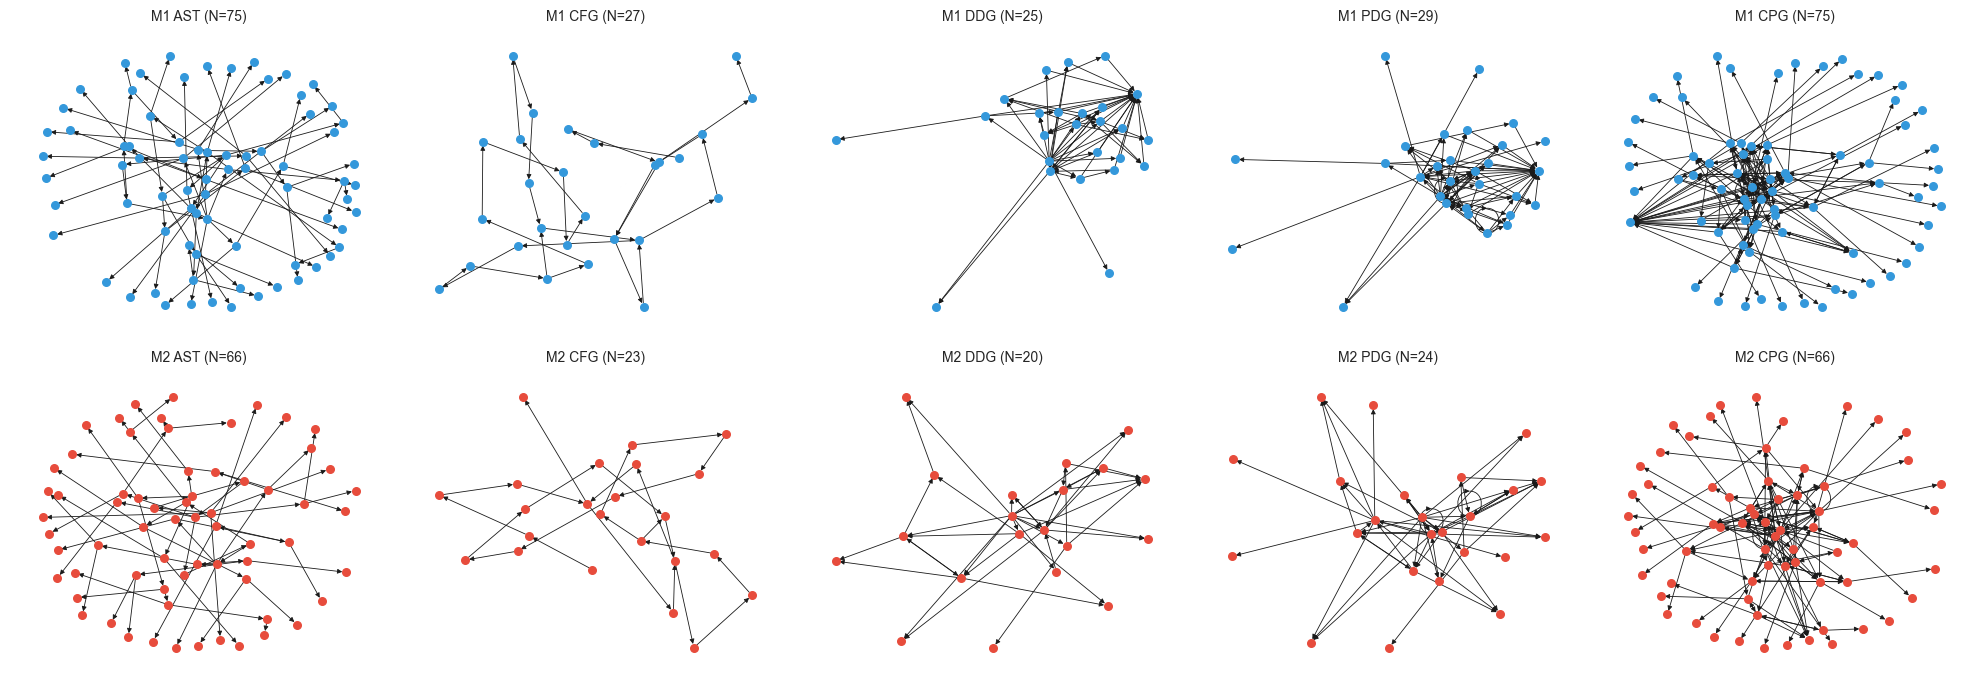

,pss_ast,hk_ast,js_ast,ws_ast,pss_cfg,hk_cfg,js_cfg,ws_cfg,pss_ddg,hk_ddg,js_ddg,ws_ddg,pss_pdg,hk_pdg,js_pdg,ws_pdg,pss_cpg,hk_cpg,js_cpg,ws_cpg
1794,0.5195,0.9960,0.7414,0.9733,0.5538,0.9803,0.6077,0.9545,0.6671,0.9912,0.5275,0.9348,0.6509,0.9916,0.6136,0.9434,0.5951,0.9952,0.7355,0.9722


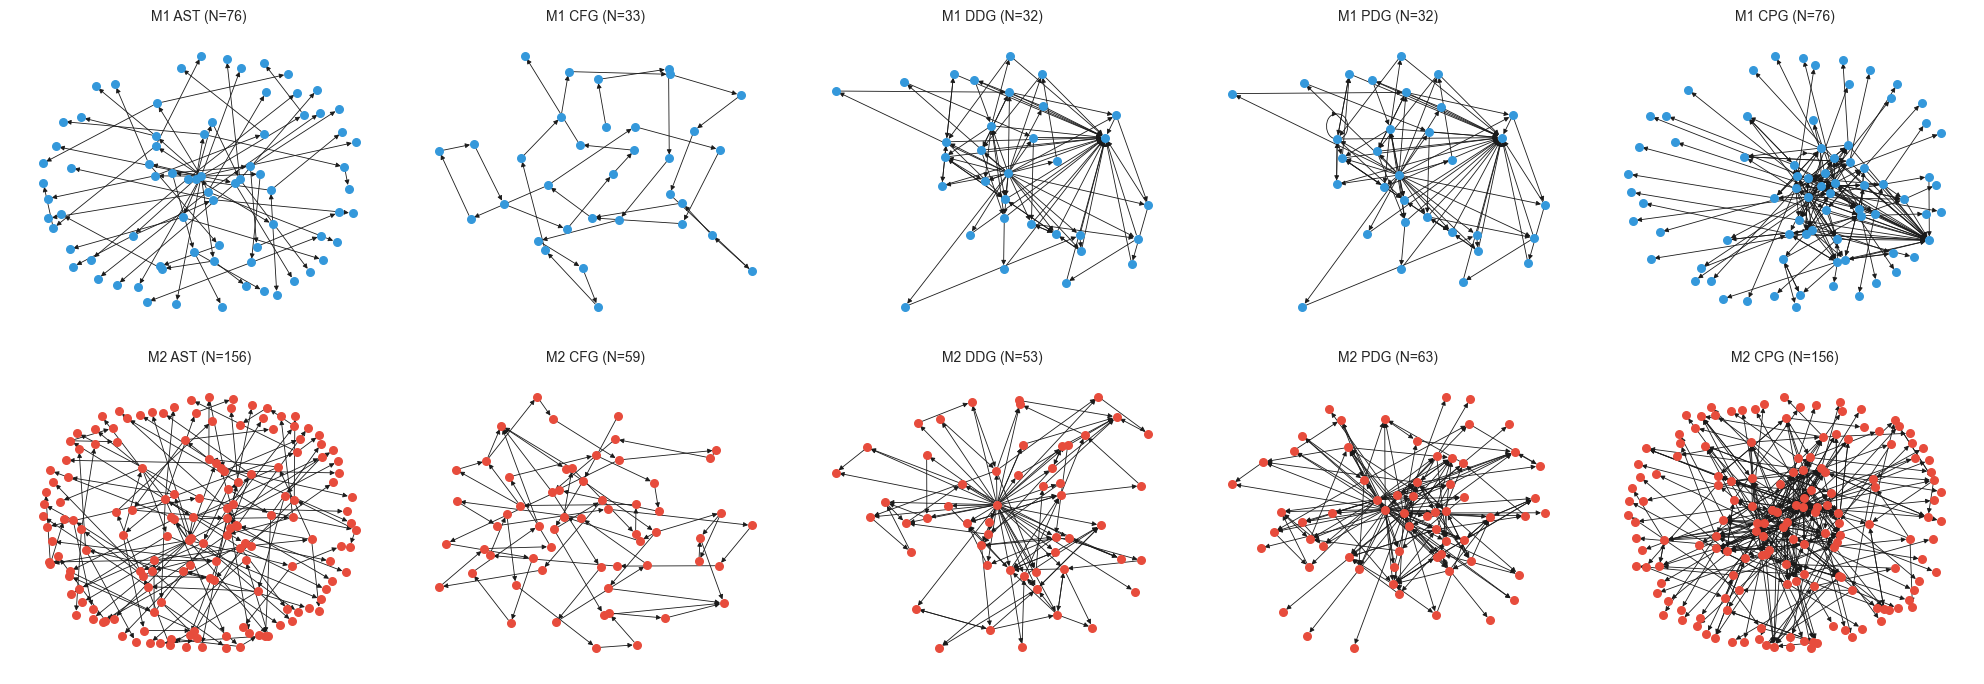

,pss_ast,hk_ast,js_ast,ws_ast,pss_cfg,hk_cfg,js_cfg,ws_cfg,pss_ddg,hk_ddg,js_ddg,ws_ddg,pss_pdg,hk_pdg,js_pdg,ws_pdg,pss_cpg,hk_cpg,js_cpg,ws_cpg
888,0.3347,0.9932,0.6323,0.9499,0.4127,0.9723,0.3649,0.9257,0.4899,0.9720,0.4785,0.9410,0.4928,0.9723,0.4479,0.9424,0.4166,0.9874,0.5542,0.9636


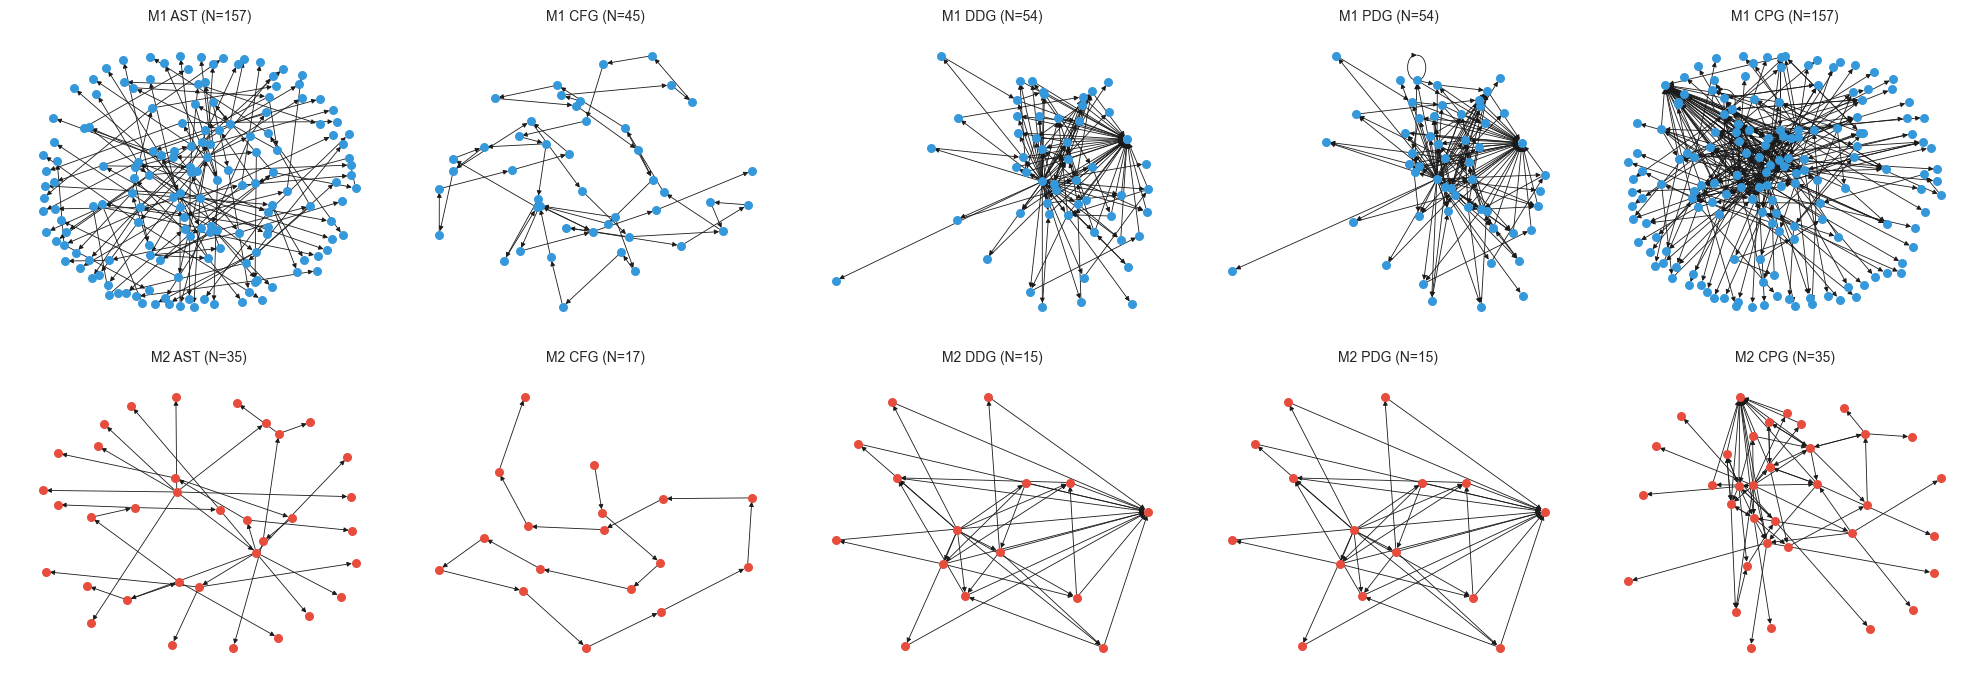

,pss_ast,hk_ast,js_ast,ws_ast,pss_cfg,hk_cfg,js_cfg,ws_cfg,pss_ddg,hk_ddg,js_ddg,ws_ddg,pss_pdg,hk_pdg,js_pdg,ws_pdg,pss_cpg,hk_cpg,js_cpg,ws_cpg
1793,0.4560,0.9997,0.7681,0.9806,0.4019,0.9895,0.5454,0.9659,0.5510,0.9888,0.6866,0.9653,0.5715,0.9894,0.6762,0.9518,0.5430,0.9908,0.7749,0.9685


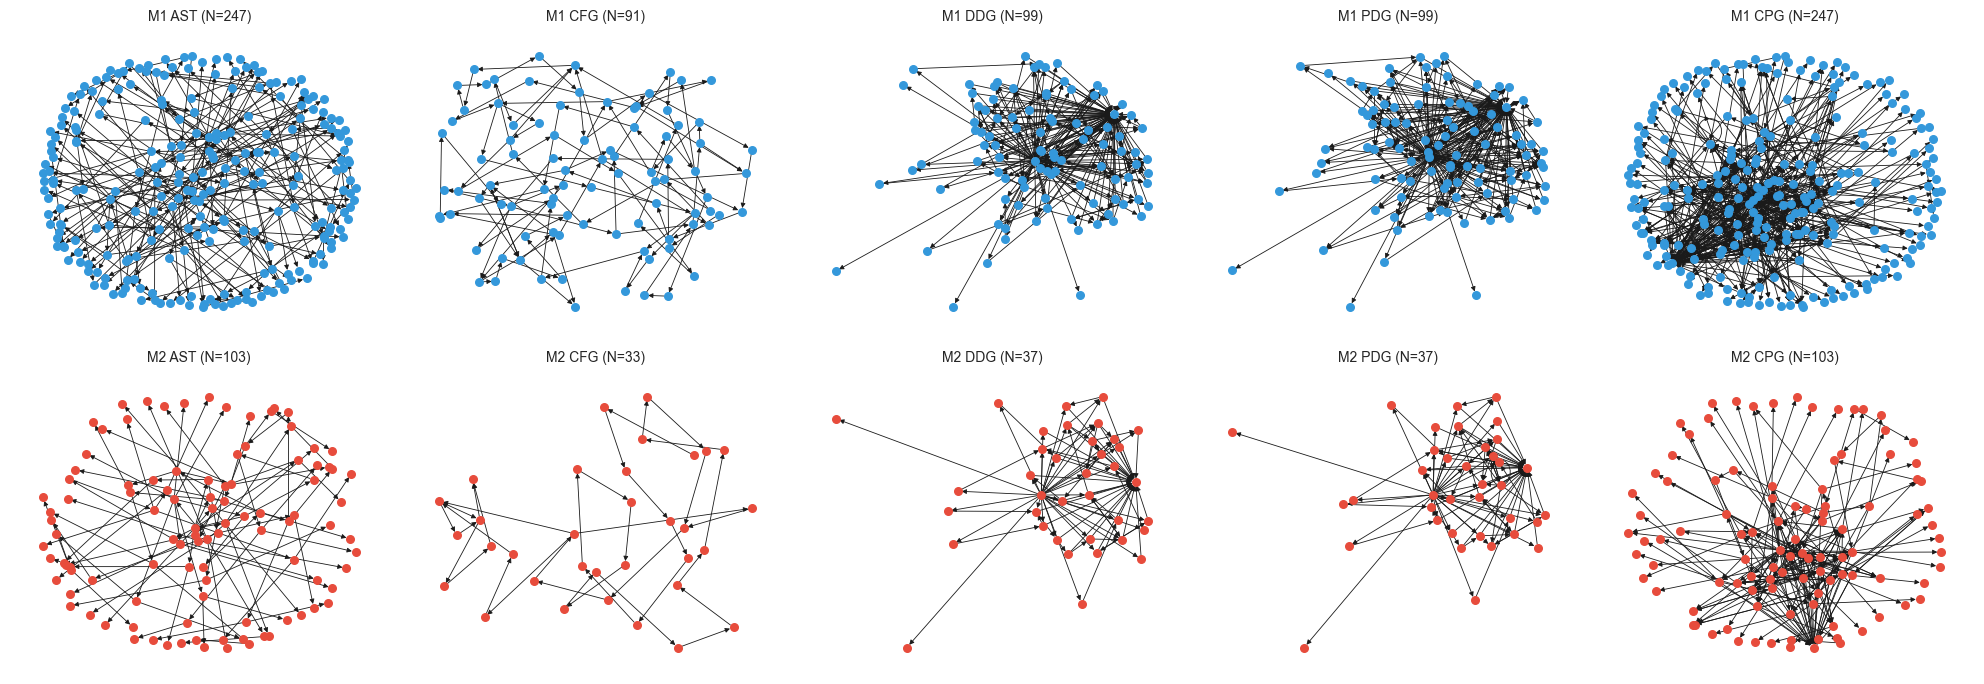

In [56]:
# --- SECTION 3: QUALITATIVE ANALYSIS & CONFUSION MATRIX SAMPLES ---
display(HTML("<hr><h1>Section 3: REALITY CHECK (TP, FP, FN, TN Samples)</h1>"))

# Initialize code map and graph db
source_code_map = {}
if JSONL_DATA.exists():
    with open(JSONL_DATA, "r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                # Store as str(int(idx)) to ensure we match CSV's potentially float-converted IDs
                source_code_map[str(int(item['idx']))] = item['func']
            except:
                continue

GRAPH_DB_PATH = OUTPUTS_DIR / "clean_graphs" / "cleaned_graphs_db.pkl"
graph_db = {}
if GRAPH_DB_PATH.exists():
    with open(GRAPH_DB_PATH, "rb") as f:
        graph_db = pickle.load(f)

def inspect_pair_manually(pair_row, title_prefix=""):
    # Fix ID conversion: handle floats like 8070429.0 -> "8070429"
    id1 = str(int(float(pair_row['id1'])))
    id2 = str(int(float(pair_row['id2'])))
    
    label = "Clone (1)" if pair_row['label'] == 1 else "Non-Clone (0)"
    
    display(HTML(f"<h3>{title_prefix} | ID: {id1} vs {id2} | Reality: <span style='color: {'green' if pair_row['label']==1 else 'red'}'>{label}</span></h3>"))
    
    # 1. Source Code Extraction
    c1 = source_code_map.get(id1, f"[-] Source code for ID {id1} not found in {JSONL_DATA.name}")
    c2 = source_code_map.get(id2, f"[-] Source code for ID {id2} not found in {JSONL_DATA.name}")
    
    # Simple HTML escape to prevent pre-tag breakages
    c1_clean = c1.replace("<", "&lt;").replace(">", "&gt;")
    c2_clean = c2.replace("<", "&lt;").replace(">", "&gt;")

    code_html = f"""
    <div style="display: flex; gap: 20px;">
        <div style="flex: 1; overflow: auto; max-height: 400px; border: 1px solid #ddd; padding: 10px; background: #fdfdfd;">
            <p style="border-bottom: 1px solid #eee;"><b>Method {id1}</b></p>
            <pre style="font-size: 11px; white-space: pre-wrap;">{c1_clean}</pre>
        </div>
        <div style="flex: 1; overflow: auto; max-height: 400px; border: 1px solid #ddd; padding: 10px; background: #fdfdfd;">
            <p style="border-bottom: 1px solid #eee;"><b>Method {id2}</b></p>
            <pre style="font-size: 11px; white-space: pre-wrap;">{c2_clean}</pre>
        </div>
    </div>
    """
    display(HTML(code_html))
    
    # 2. Similarity Breakdown
    metric_cols = [c for c in pair_row.index if any(m in c.lower() for m in metrics)]
    # Use to_frame().T to avoid object/string coercion if possible, or force numeric
    m_summary = pair_row[metric_cols].to_frame().T
    m_summary = m_summary.apply(pd.to_numeric, errors='coerce') # Force everything to numeric/NaN
    
    display(HTML("<b>Calculated Similarities:</b>"))
    # Format only the columns that actually exist and are numeric
    fmt_dict = {c: "{:.4f}" for c in m_summary.columns}
    display(m_summary.style.format(fmt_dict, na_rep="-").background_gradient(cmap="YlGnBu", axis=1))
    
    # 3. Graph Render
    if id1 in graph_db and id2 in graph_db:
        fig, axes = plt.subplots(2, 5, figsize=(20, 7))
        for i, layer in enumerate(layers):
            g1 = graph_db[id1].get(layer)
            g2 = graph_db[id2].get(layer)
            for j, g in enumerate([g1, g2]):
                ax = axes[j, i]
                if g is not None and g.number_of_nodes() > 0:
                    pos = nx.spring_layout(g, seed=42, k=0.5)
                    nx.draw(g, pos, ax=ax, node_size=30, node_color="#3498db" if j==0 else "#e74c3c", 
                            width=0.6, arrows=True, arrowsize=7, with_labels=False)
                    ax.set_title(f"M{j+1} {layer.upper()} (N={g.number_of_nodes()})", fontsize=10)
                else:
                    ax.text(0.5, 0.5, "Empty Graph", ha='center', va='center')
                ax.set_axis_off()
        plt.tight_layout()
        plt.show()
    else:
        print(f"[-] Graphs for IDs {id1} or {id2} not found in database.")

# --- DIAGNOSTIC CLASSIFICATION ---
if not df_sim.empty:
    # Use PSS_CFG as a reference threshold from Section 1 if available, else 0.5
    ref_th = 0.5
    if 'df_merged' in locals():
        match = df_merged[(df_merged['Layer'] == 'CFG') & (df_merged['Metric'] == 'PSS')]
        if not match.empty:
            ref_th = match['Optimum_Threshold'].values[0]

    # Classify samples roughly based on the threshold
    if 'pss_cfg' in df_sim.columns:
        df_sim['pred'] = (df_sim['pss_cfg'] >= ref_th).astype(int)
        
        tp_cond = (df_sim['label'] == 1) & (df_sim['pred'] == 1)
        fp_cond = (df_sim['label'] == 0) & (df_sim['pred'] == 1)
        fn_cond = (df_sim['label'] == 1) & (df_sim['pred'] == 0)
        tn_cond = (df_sim['label'] == 0) & (df_sim['pred'] == 0)

        samples = [
            (df_sim[tp_cond].sample(1).iloc[0] if not df_sim[tp_cond].empty else None, "TRUE POSITIVE (Caught Clone)"),
            (df_sim[fp_cond].sample(1).iloc[0] if not df_sim[fp_cond].empty else None, "FALSE POSITIVE (False Alarm)"),
            (df_sim[fn_cond].sample(1).iloc[0] if not df_sim[fn_cond].empty else None, "FALSE NEGATIVE (Missed Clone)"),
            (df_sim[tn_cond].sample(1).iloc[0] if not df_sim[tn_cond].empty else None, "TRUE NEGATIVE (Correct Reject)")
        ]

        for s, title in samples:
            if s is not None:
                inspect_pair_manually(s, title)
                display(HTML("<hr style='border: 1px dashed #ccc;'>"))
    else:
        print("[-] 'pss_cfg' column missing. Cannot perform prediction sampling.")


,Strategy,Clone Mean,Non-Clone Mean,Gap (Separation),Max Score,Min Score
4,CONTRAST_CFG,0.1480,0.1339,0.0140,1.000000,0.002168
2,FUSION_MULT,0.3396,0.3337,0.0060,1.000000,0.086195
0,PSS_CFG,0.5417,0.5377,0.0040,1.000000,0.293239
3,FUSION_HARMONIC,0.5455,0.5429,0.0026,1.000000,0.293590
1,PSS_AST,0.5540,0.5524,0.0017,1.000000,0.293783


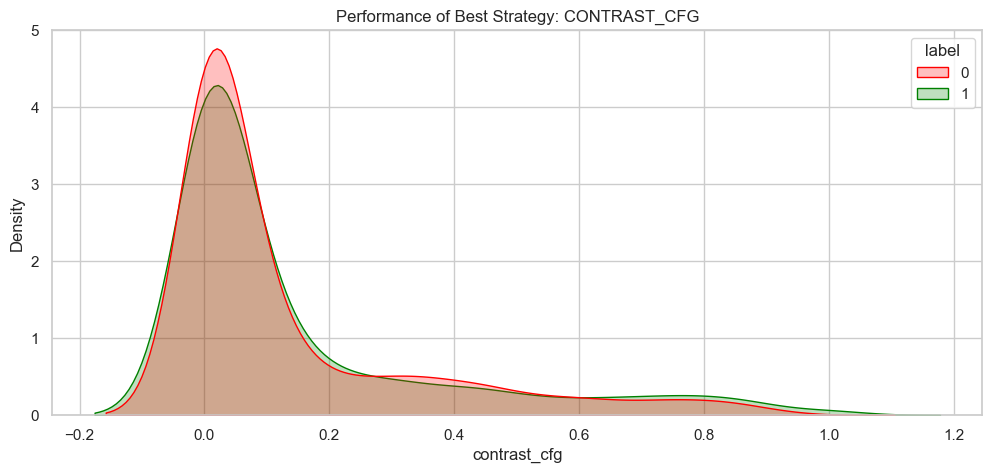

In [57]:
# --- SECTION 4: ADVANCED FUSION & SCALING STRATEGIES ---
display(HTML("<hr><h1>Section 4: Advanced Fusion & Scaling</h1>"))

if not df_sim.empty:
    df_fusion = df_sim.copy()
    
    # 1. PSS Improvement: Size Normalization
    # Re-calculating a 'balanced' PSS by penalizing size difference
    # because eigenvectors/eigenvalues are scale-dependent in non-normalized Laplacians.
    if 'cfg_avg_nodes' in df_fusion.columns:
        # Penalty factor: e^(-|n1-n2| / avg_n)
        size_penalty = np.exp(-abs(df_fusion['cfg_n1'] - df_fusion['cfg_n2']) / (df_fusion['cfg_avg_nodes'] + 1))
        df_fusion['pss_cfg_size_aware'] = df_fusion['pss_cfg'] * size_penalty

    # 2. Layer Combination (FUSION)
    # Using PSS_CFG and PSS_AST as a pair.
    if 'pss_cfg' in df_fusion.columns and 'pss_ast' in df_fusion.columns:
        # Multiplication often works better than addition for "AND" logic (must be similar in both)
        df_fusion['fusion_mult'] = df_fusion['pss_cfg'] * df_fusion['pss_ast']
        # Harmonic mean (penalizes low scores in either layer)
        df_fusion['fusion_harmonic'] = 2 * (df_fusion['pss_cfg'] * df_fusion['pss_ast']) / (df_fusion['pss_cfg'] + df_fusion['pss_ast'] + 1e-9)

    # 3. Non-Linear Separation (Aggressive Contrast)
    # Power-scaling: Sim^P where P > 1. This pushes values away from each other.
    if 'pss_cfg' in df_fusion.columns:
        df_fusion['contrast_cfg'] = df_fusion['pss_cfg'] ** 5 # High power for extreme contrast

    # --- GAP ANALYSIS TABLE ---
    test_cols = [c for c in ["pss_cfg", "pss_ast", "pss_cfg_size_aware", "fusion_mult", "fusion_harmonic", "contrast_cfg"] if c in df_fusion.columns]
    gap_analysis = []
    
    for c in test_cols:
        m1 = df_fusion[df_fusion['label']==1][c].mean()
        m0 = df_fusion[df_fusion['label']==0][c].mean()
        gap_analysis.append({
            "Strategy": c.upper(),
            "Clone Mean": m1,
            "Non-Clone Mean": m0,
            "Gap (Separation)": m1 - m0,
            "Max Score": df_fusion[c].max(),
            "Min Score": df_fusion[c].min()
        })
    
    df_gap = pd.DataFrame(gap_analysis).sort_values("Gap (Separation)", ascending=False)
    display(HTML("<h3>Discriminative Strategy Comparison</h3>"))
    display(df_gap.style.background_gradient(subset=["Gap (Separation)"], cmap="RdYlGn")
                    .format({k: "{:.4f}" for k in ["Clone Mean", "Non-Clone Mean", "Gap (Separation)"]}))

    # 4. Visualization of Winner
    winner = df_gap.iloc[0]["Strategy"].lower()
    plt.figure(figsize=(12, 5))
    sns.kdeplot(data=df_fusion, x=winner, hue="label", fill=True, palette={1: "green", 0: "red"}, common_norm=False)
    plt.title(f"Performance of Best Strategy: {winner.upper()}")
    plt.show()



In [58]:
# --- SECTION 5: NEW SPECTRAL EVALUATION (INTERPOLATION MODE) ---
display(HTML("<hr><h1>Section 5: New PSS (Spectral Interpolation) Diagnostic</h1>"))

def pss_interpolation(ev1, ev2):
    def strip(ev):
        nz = np.nonzero(ev)[0]
        return ev[:nz[-1]+1] if len(nz) > 0 else ev
    
    e1, e2 = strip(ev1), strip(ev2)
    if len(e1) < 2 or len(e2) < 2: return 0.0
    
    # Resample to common size (Interpolation)
    max_len = max(len(e1), len(e2))
    v1 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(e1)), e1)
    v2 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(e2)), e2)
    
    # L2 Norm
    v1_n = v1 / (np.linalg.norm(v1) + 1e-9)
    v2_n = v2 / (np.linalg.norm(v2) + 1e-9)
    
    dist = np.linalg.norm(v1_n - v2_n)
    return (np.sqrt(2) - dist) / np.sqrt(2)

if 'spec_db' in locals():
    # 1. Calculate Gap on AST
    results_new = []
    # Larger sample for stats
    sample_df = df_sim.sample(min(1000, len(df_sim)))
    
    for _, row in sample_df.iterrows():
        id1, id2 = str(int(float(row['id1']))), str(int(float(row['id2'])))
        if id1 in spec_db and id2 in spec_db:
            ev1 = spec_db[id1].get('ast', {}).get('eigenvalues', np.array([]))
            ev2 = spec_db[id2].get('ast', {}).get('eigenvalues', np.array([]))
            
            score = pss_interpolation(ev1, ev2)
            results_new.append({"label": row['label'], "score": score, "id1": id1, "id2": id2})
            
    df_new = pd.DataFrame(results_new)
    if not df_new.empty:
        m1 = df_new[df_new['label']==1]['score'].mean()
        m0 = df_new[df_new['label']==0]['score'].mean()
        gap = m1 - m0
        
        display(HTML(f"<h3>Current Gap (Interpolation Mode): <span style='color: {'green' if gap > 0.05 else 'orange'}'>{gap:.4f}</span></h3>"))
        display(HTML(f"<b>Clone Avg:</b> {m1:.4f} | <b>Non-Clone Avg:</b> {m0:.4f}"))
        
        # 2. Pick a "Perfect" Clone and a "Tricky" Non-Clone to show side-by-side
        best_clone = df_new[df_new['label']==1].sort_values("score", ascending=False).iloc[0]
        worst_non_clone = df_new[df_new['label']==0].sort_values("score", ascending=False).iloc[0]
        
        print("\n[+] DIAGNOSTIC: Comparing a High-Score Clone vs a High-Score Non-Clone")
        inspect_pair_manually(best_clone, "HIGH SCORE CLONE (Success Case)")
        inspect_pair_manually(worst_non_clone, "HIGH SCORE NON-CLONE (False Positive Case)")
        
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df_new, x="score", hue="label", fill=True, common_norm=False)
        plt.axvline(m1, color='green', linestyle='--', label='Clone Mean')
        plt.axvline(m0, color='red', linestyle='--', label='Non-Clone Mean')
        plt.title("Distribution of New Interpolated Scores")
        plt.legend()
        plt.show()
    else:
        print("[-] Data calculation failed.")
else:
    print("[-] spec_db not loaded.")


[-] spec_db not loaded.


In [59]:
# --- SECTION 6: SYNTHETIC STRESS TEST (PSS vs WATERSTEIN) ---
import networkx as nx
import warnings
from scipy.stats import wasserstein_distance

display(HTML("<hr><h1>Section 6: Synthetic Diagnostic (PSS vs Wasserstein)</h1>"))

def get_eigenvalues(G):
    # Mimic DirectedLaplacian logic from the pipeline
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        L = nx.directed_laplacian_matrix(G, alpha=0.95)
    eigvals = np.linalg.eigvals(L)
    return np.sort(np.real(eigvals))

def compute_metrics(ev1, ev2):
    # PSS (Interpolated)
    pss = pss_interpolation(ev1, ev2)
    
    # Wasserstein (Normalized to 0-1 similarity)
    # 1. Resample to same size
    max_len = max(len(ev1), len(ev2))
    v1 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(ev1)), ev1)
    v2 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(ev2)), ev2)
    dist_w = wasserstein_distance(v1, v2)
    sim_w = 1 / (1 + dist_w)
    
    return pss, sim_w

# 1. Base Graph (Tree)
base_ast = nx.balanced_tree(r=2, h=4, create_using=nx.DiGraph())
ev_base = get_eigenvalues(base_ast)

# 2. Clone (Modified Tree)
clone_ast = base_ast.copy()
clone_ast.add_edge(30, 31); clone_ast.add_edge(31, 32)
ev_clone = get_eigenvalues(clone_ast)

# 3. Outlier (Star Graph)
outlier_graph = nx.star_graph(n=20).to_directed()
ev_outlier = get_eigenvalues(outlier_graph)

# Compute
pss_c, w_c = compute_metrics(ev_base, ev_clone)
pss_o, w_o = compute_metrics(ev_base, ev_outlier)

# RESULTS
res_syn = pd.DataFrame([
    {"Pair": "Base vs Clone", "PSS Sim": pss_c, "W-Sim": w_c},
    {"Pair": "Base vs Outlier", "PSS Sim": pss_o, "W-Sim": w_o}
])

display(res_syn.style.background_gradient(cmap="RdYlGn", axis=0))

gap_pss = pss_c - pss_o
gap_w = w_c - w_o
print(f"\n[!] GAP ANALYSIS:")
print(f"    PSS GAP: {gap_pss:.4f}")
print(f"    WASSERSTEIN GAP: {gap_w:.4f}")


,Pair,PSS Sim,W-Sim
0,Base vs Clone,0.978834,0.982341
1,Base vs Outlier,0.814982,0.674504



[!] GAP ANALYSIS:
    PSS GAP: 0.1639
    WASSERSTEIN GAP: 0.3078


,Pair,PSS Score,Target
0,Tree vs Similar Tree,0.961558,HIGH (Clone)
1,Tree vs Path Graph,0.809240,LOW (Outlier)
2,Tree vs Star Graph,0.796406,LOW (Outlier)


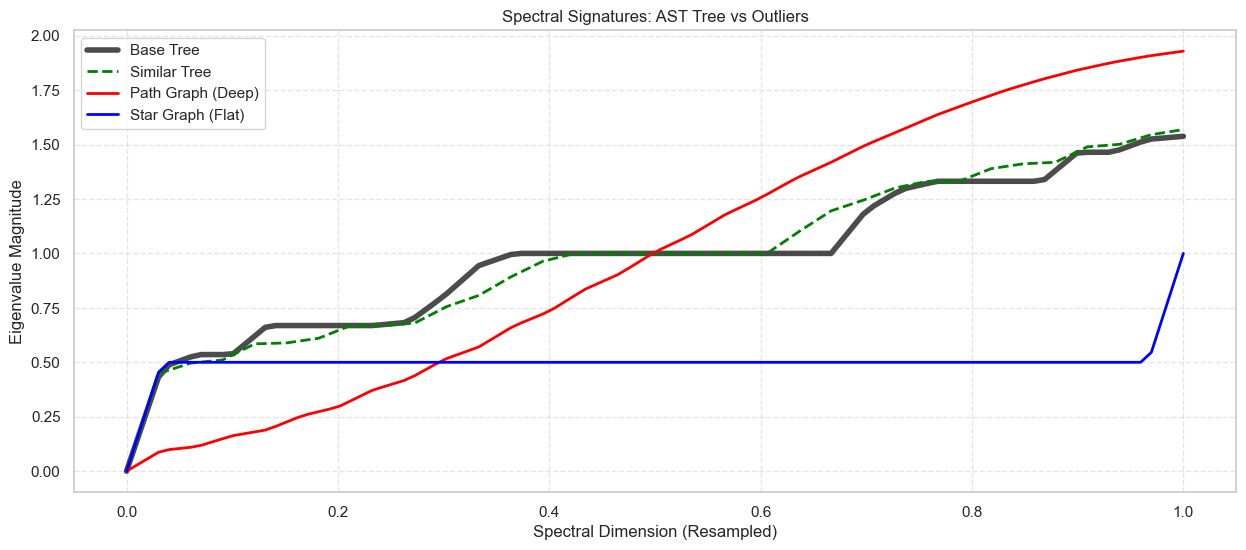

In [60]:
# --- SECTION 7: PSS BASELINE TEST (AST ONLY) ---
display(HTML("<hr><h1>Section 7: PSS Sensitivity Baseline (Synthetic Case)</h1>"))

def get_ast_spectral_signature(G):
    # Standard Directed Laplacian for AST
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        L = nx.directed_laplacian_matrix(G, alpha=0.95)
    return np.sort(np.real(np.linalg.eigvals(L)))

# 1. GENERATE SYNTHETIC GRAPHS
# Case A: Base Tree (r=2, h=4)
g_base = nx.balanced_tree(r=2, h=4, create_using=nx.DiGraph())
ev_base = get_ast_spectral_signature(g_base)

# Case B: Similar Tree (Clone candidate - add 3 leaf nodes)
g_similar = g_base.copy()
n_nodes = g_similar.number_of_nodes()
for i in range(3):
    g_similar.add_edge(random.randint(15, 30), n_nodes + i)
ev_similar = get_ast_spectral_signature(g_similar)

# Case C: Linear/Path Graph (Outlier 1 - Totally different topology)
g_path = nx.path_graph(31, create_using=nx.DiGraph())
ev_path = get_ast_spectral_signature(g_path)

# Case D: Star Graph (Outlier 2 - Hub-and-Spoke topology)
g_star = nx.star_graph(30).to_directed()
ev_star = get_ast_spectral_signature(g_star)

# 2. COMPUTE PSS SCORES (Using Interpolation)
score_sim = pss_interpolation(ev_base, ev_similar)
score_path = pss_interpolation(ev_base, ev_path)
score_star = pss_interpolation(ev_base, ev_star)

# 3. DISPLAY RESULTS
res_baseline = pd.DataFrame([
    {"Pair": "Tree vs Similar Tree", "PSS Score": score_sim, "Target": "HIGH (Clone)"},
    {"Pair": "Tree vs Path Graph", "PSS Score": score_path, "Target": "LOW (Outlier)"},
    {"Pair": "Tree vs Star Graph", "PSS Score": score_star, "Target": "LOW (Outlier)"}
])

display(res_baseline.style.background_gradient(cmap="RdYlGn", subset=["PSS Score"]))

# 4. PLOT SPECTRA
plt.figure(figsize=(15, 6))
x_axis = np.linspace(0, 1, 100) # Resampled x-axis for visualization

def resample(ev, target_len=100):
    return np.interp(np.linspace(0, 1, target_len), np.linspace(0, 1, len(ev)), ev)

plt.plot(x_axis, resample(ev_base), label='Base Tree', linewidth=4, color='black', alpha=0.7)
plt.plot(x_axis, resample(ev_similar), label='Similar Tree', linestyle='--', linewidth=2, color='green')
plt.plot(x_axis, resample(ev_path), label='Path Graph (Deep)', linewidth=2, color='red')
plt.plot(x_axis, resample(ev_star), label='Star Graph (Flat)', linewidth=2, color='blue')

plt.title("Spectral Signatures: AST Tree vs Outliers")
plt.xlabel("Spectral Dimension (Resampled)")
plt.ylabel("Eigenvalue Magnitude")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()


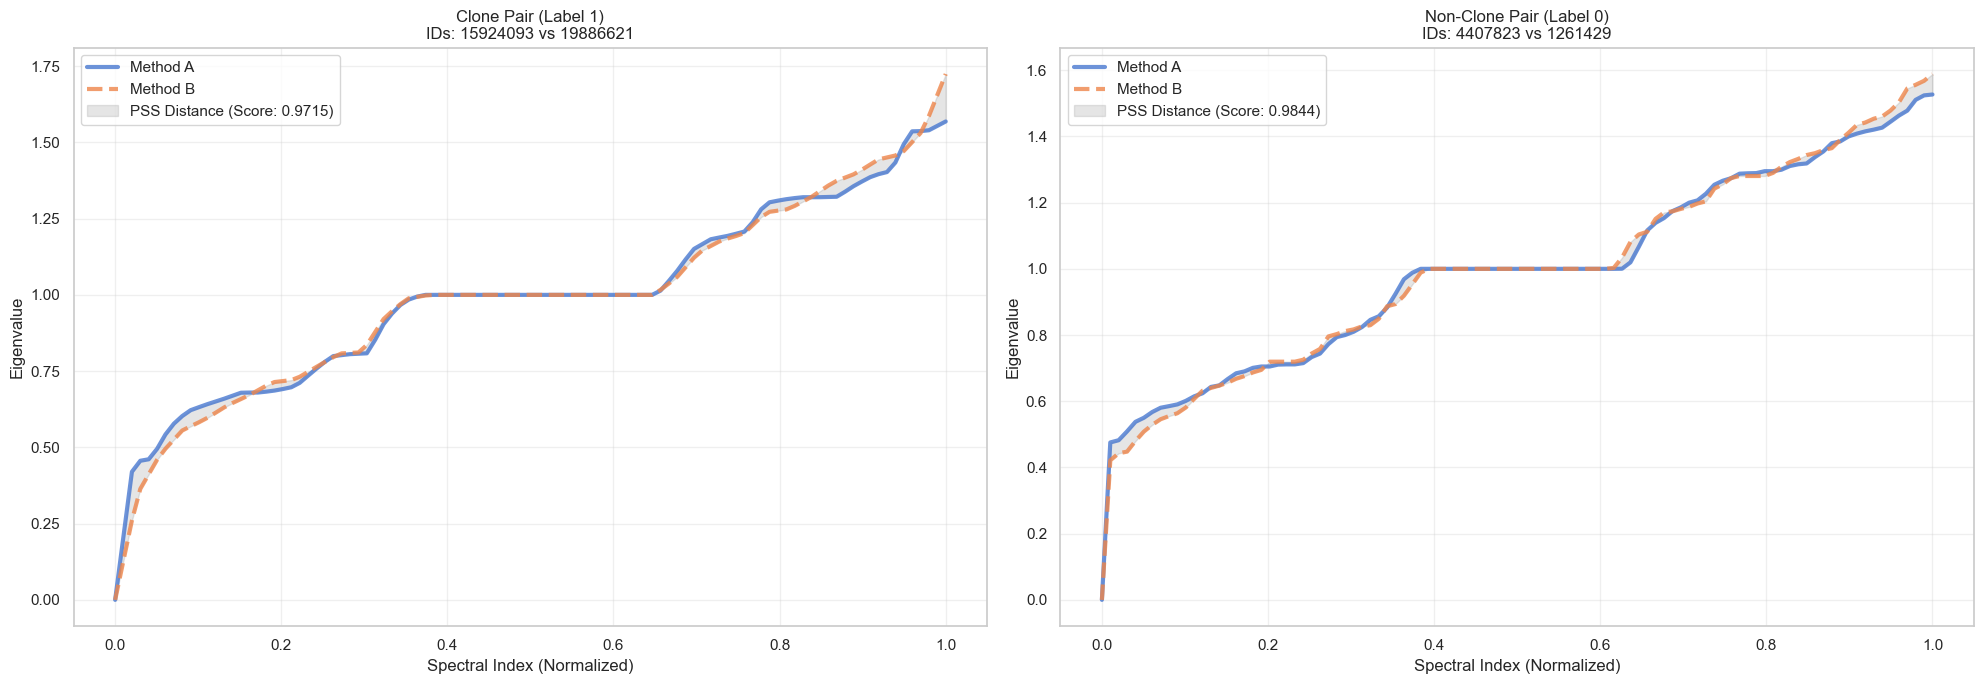

In [61]:
# --- SECTION 8: REAL DATA SPECTRAL SIGNATURES (AST) ---
display(HTML("<hr><h1>Section 8: REAL DATA Reality Check (AST Spectrum)</h1>"))

# 1. Select representative pairs
# We'll pick one Clone (Label=1) and one Non-Clone (Label=0)
tp_sample = df_sim[df_sim['label'] == 1].iloc[0] if not df_sim[df_sim['label'] == 1].empty else None
tn_sample = df_sim[df_sim['label'] == 0].iloc[0] if not df_sim[df_sim['label'] == 0].empty else None

def get_pair_spectra(pair_row):
    id1 = str(int(float(pair_row['id1'])))
    id2 = str(int(float(pair_row['id2'])))
    
    g1 = graph_db.get(id1, {}).get('ast')
    g2 = graph_db.get(id2, {}).get('ast')
    
    if g1 is None or g2 is None:
        return None, None
        
    ev1 = get_ast_spectral_signature(g1)
    ev2 = get_ast_spectral_signature(g2)
    return ev1, ev2

# Plotting function for pair comparison
def plot_pair_spectra(ax, ev1, ev2, title, pss_score):
    x_axis = np.linspace(0, 1, 100)
    v1 = resample(ev1)
    v2 = resample(ev2)
    
    ax.plot(x_axis, v1, label='Method A', linewidth=3, alpha=0.8)
    ax.plot(x_axis, v2, label='Method B', linewidth=3, alpha=0.8, linestyle='--')
    ax.fill_between(x_axis, v1, v2, color='gray', alpha=0.2, label=f'PSS Distance (Score: {pss_score:.4f})')
    
    ax.set_title(title)
    ax.set_xlabel("Spectral Index (Normalized)")
    ax.set_ylabel("Eigenvalue")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Execution
if tp_sample is not None and tn_sample is not None:
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    
    # Process Clone Pair
    ev_c1, ev_c2 = get_pair_spectra(tp_sample)
    if ev_c1 is not None:
        score_c = pss_interpolation(ev_c1, ev_c2)
        plot_pair_spectra(axes[0], ev_c1, ev_c2, f"Clone Pair (Label 1)\nIDs: {int(tp_sample['id1'])} vs {int(tp_sample['id2'])}", score_c)
    
    # Process Non-Clone Pair
    ev_n1, ev_n2 = get_pair_spectra(tn_sample)
    if ev_n1 is not None:
        score_n = pss_interpolation(ev_n1, ev_n2)
        plot_pair_spectra(axes[1], ev_n1, ev_n2, f"Non-Clone Pair (Label 0)\nIDs: {int(tn_sample['id1'])} vs {int(tn_sample['id2'])}", score_n)
    
    plt.tight_layout()
    plt.show()
else:
    print("[-] Missing samples for visualization.")


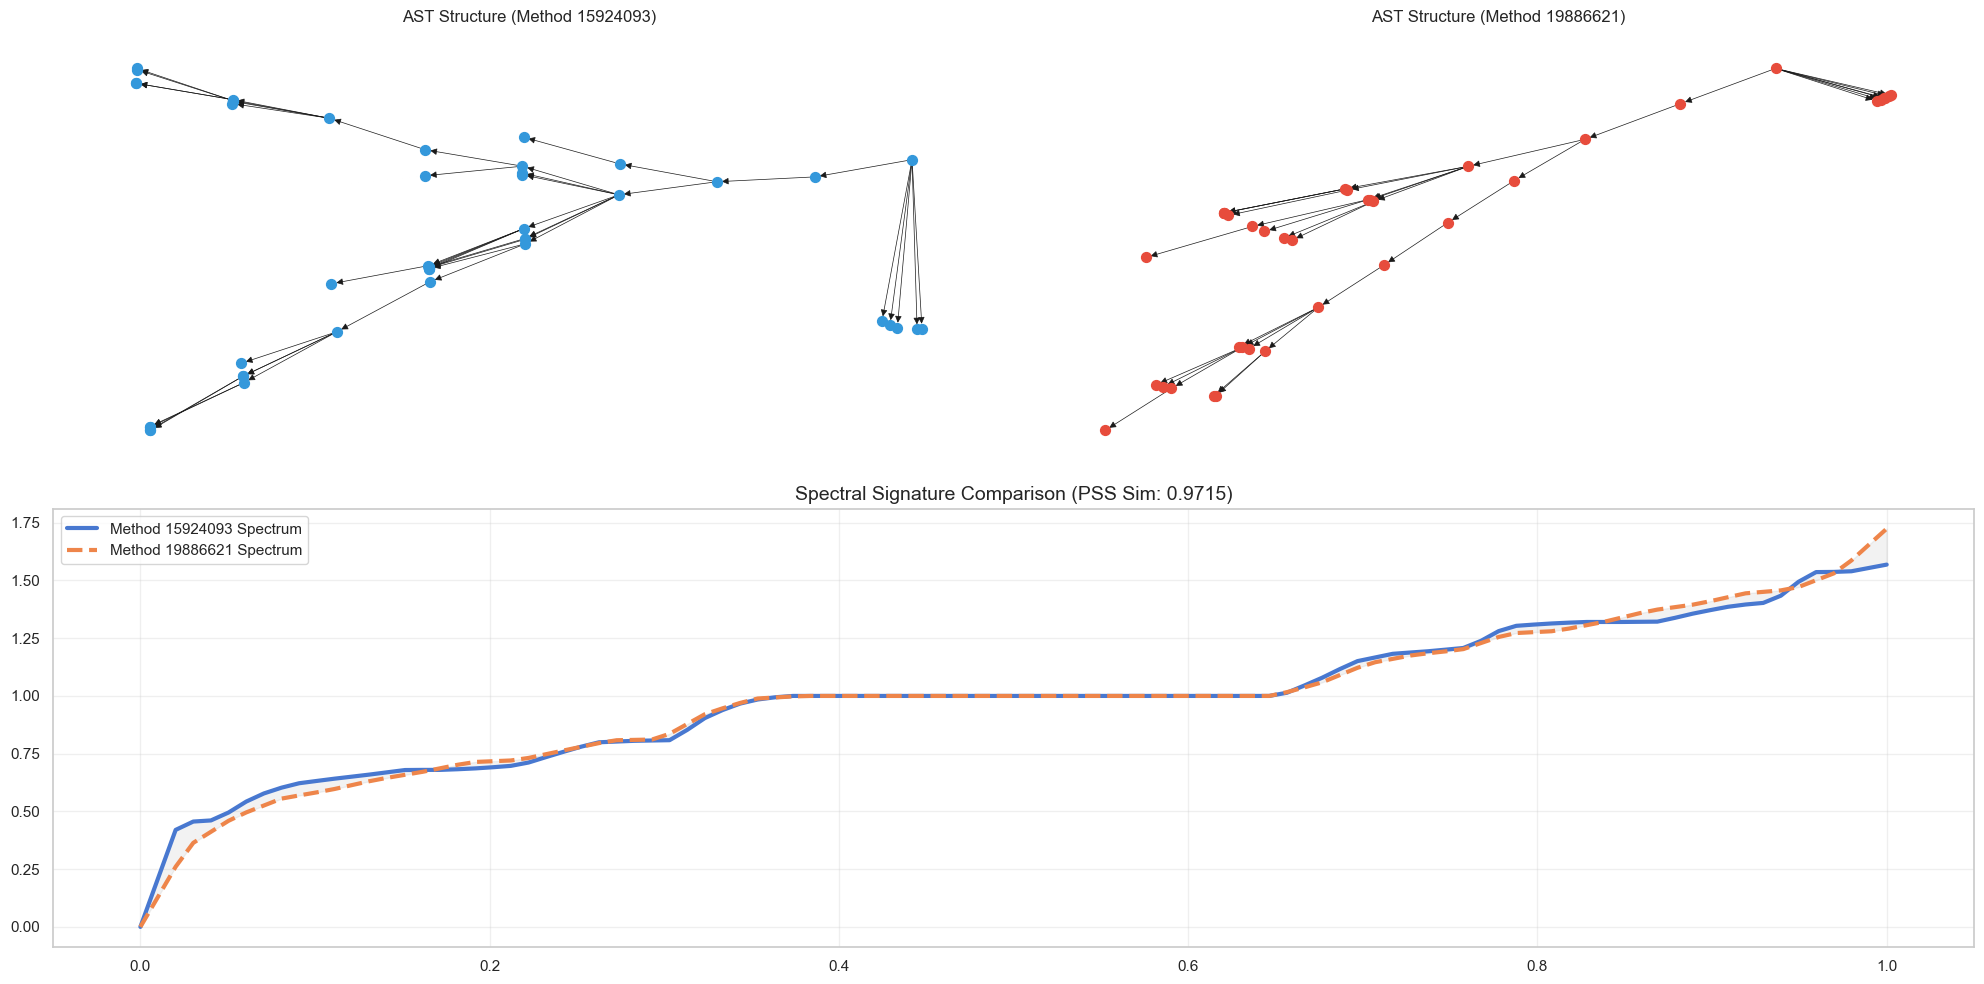

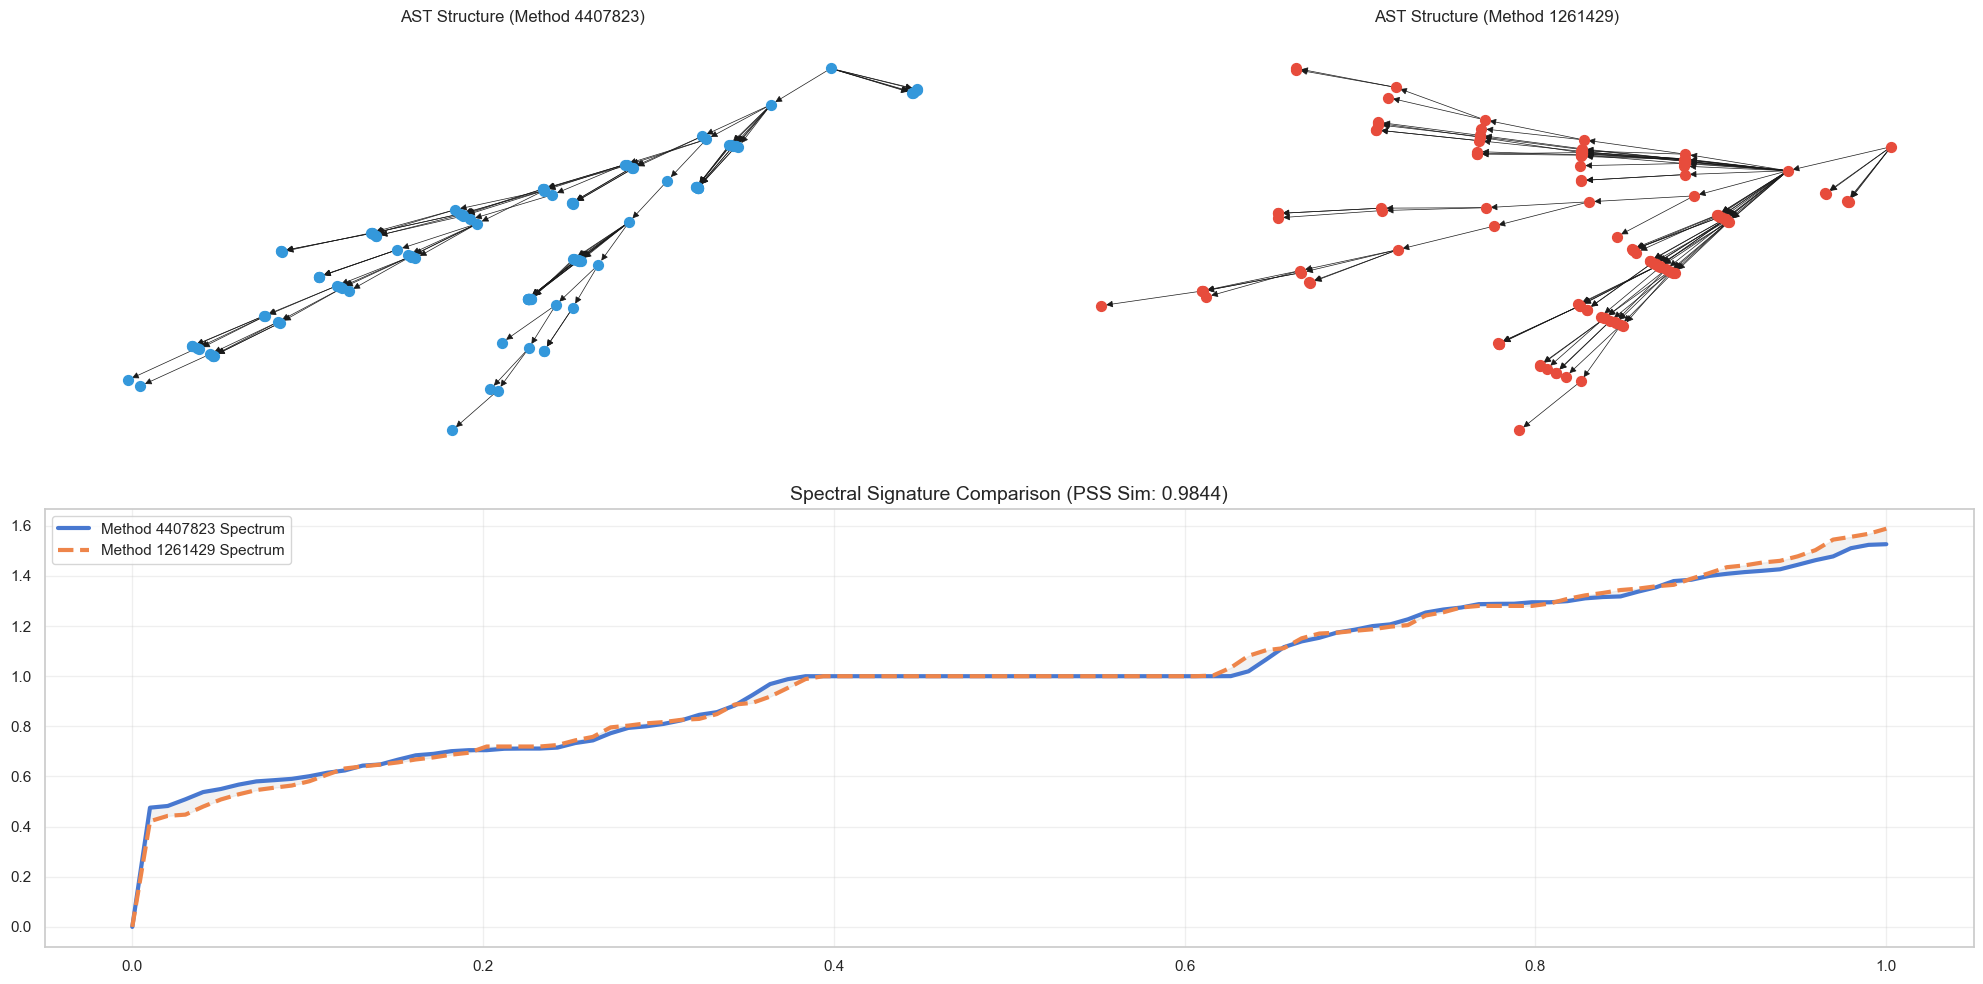

In [62]:
# --- SECTION 9: TRIPLE VIEW (Code + Graph + Spectrum) ---
display(HTML("<hr><h1>Section 9: Diagnostic Triple View (AST Deep Dive)</h1>"))

def visualize_triple_view(pair_row, title=""):
    id1 = str(int(float(pair_row['id1'])))
    id2 = str(int(float(pair_row['id2'])))
    label = "Clone (1)" if pair_row['label'] == 1 else "Non-Clone (0)"
    
    display(HTML(f"<h2>{title} | ID: {id1} vs {id2} | Reality: {label}</h2>"))
    
    # 1. Source Code
    c1 = source_code_map.get(id1, "Source not found")
    c2 = source_code_map.get(id2, "Source not found")
    
    code_html = f"""
    <div style="display: flex; gap: 10px; margin-bottom: 20px;">
        <div style="flex: 1; max-height: 300px; overflow: auto; border: 1px solid #ddd; padding: 5px; background: #fafafa;">
            <b>Method {id1}</b>
            <pre style="font-size: 10px;">{c1.replace('<','&lt;').replace('>','&gt;')}</pre>
        </div>
        <div style="flex: 1; max-height: 300px; overflow: auto; border: 1px solid #ddd; padding: 5px; background: #fafafa;">
            <b>Method {id2}</b>
            <pre style="font-size: 10px;">{c2.replace('<','&lt;').replace('>','&gt;')}</pre>
        </div>
    </div>
    """
    display(HTML(code_html))
    
    # 2. Graph & Spectrum Figure
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
    
    ax_g1 = fig.add_subplot(gs[0, 0])
    ax_g2 = fig.add_subplot(gs[0, 1])
    ax_spec = fig.add_subplot(gs[1, :])
    
    # Graphs
    g1 = graph_db.get(id1, {}).get('ast')
    g2 = graph_db.get(id2, {}).get('ast')
    
    for ax, g, color, mid in zip([ax_g1, ax_g2], [g1, g2], ["#3498db", "#e74c3c"], [id1, id2]):
        if g and g.number_of_nodes() > 0:
            pos = nx.kamada_kawai_layout(g) # Better for trees
            nx.draw(g, pos, ax=ax, node_size=50, node_color=color, width=0.5, arrows=True, with_labels=False)
            ax.set_title(f"AST Structure (Method {mid})", fontsize=12)
        else:
            ax.text(0.5, 0.5, "Graph Empty", ha='center')
        ax.set_axis_off()
        
    # Spectrum
    if g1 and g2:
        ev1 = get_ast_spectral_signature(g1)
        ev2 = get_ast_spectral_signature(g2)
        pss = pss_interpolation(ev1, ev2)
        
        x_axis = np.linspace(0, 1, 100)
        ax_spec.plot(x_axis, resample(ev1), label=f'Method {id1} Spectrum', linewidth=3)
        ax_spec.plot(x_axis, resample(ev2), label=f'Method {id2} Spectrum', linewidth=3, linestyle='--')
        ax_spec.fill_between(x_axis, resample(ev1), resample(ev2), color='gray', alpha=0.1)
        ax_spec.set_title(f"Spectral Signature Comparison (PSS Sim: {pss:.4f})", fontsize=14)
        ax_spec.legend()
        ax_spec.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Sample execution
if tp_sample is not None:
    visualize_triple_view(tp_sample, "SUCCESS CASE: High-Confidence Clone")

if tn_sample is not None:
    display(HTML("<hr>"))
    visualize_triple_view(tn_sample, "FAILURE CASE: High-Similarity Non-Clone")


In [63]:
# --- SECTION 10: AST NODES DEEP INSPECTION ---
display(HTML("<hr><h1>Section 10: AST Node Integrity Inspection</h1>"))

def inspect_ast_content(graph_id, limit=10):
    g = graph_db.get(graph_id, {}).get('ast')
    if g is None or g.number_of_nodes() == 0:
        print(f"[-] No AST found for ID {graph_id}")
        return
    
    print(f"\n[+] AST Nodes for ID {graph_id} (Total: {g.number_of_nodes()}):")
    # Join nodes with their labels/properties if available
    for i, (node, data) in enumerate(list(g.nodes(data=True))[:limit]):
        # Joern dot files usually put the node label in 'label' attribute
        label = data.get('label', 'N/A')
        print(f"  - Node {node}: {label}")
    
    if g.number_of_nodes() > limit:
        print(f"  ... (+ {g.number_of_nodes() - limit} more nodes)")

# Inspect the "Clone" pair that the user thinks isn't a clone
if tp_sample is not None:
    id1_c = str(int(float(tp_sample['id1'])))
    id2_c = str(int(float(tp_sample['id2'])))
    inspect_ast_content(id1_c)
    inspect_ast_content(id2_c)

# Also inspect the second pair
if tn_sample is not None:
    id1_n = str(int(float(tn_sample['id1'])))
    id2_n = str(int(float(tn_sample['id2'])))
    inspect_ast_content(id1_n)



[+] AST Nodes for ID 15924093 (Total: 47):
  - Node 107374187242: 2
  - Node 111669157450: 2
  - Node 111669157451: 2
  - Node 25769829444: 2
  - Node 47244656963: 3
  - Node 25769829445: 3
  - Node 94489300706: 4
  - Node 30064892726: 4
  - Node 68719591349: 4
  - Node 30064892727: 4
  ... (+ 37 more nodes)

[+] AST Nodes for ID 19886621 (Total: 38):
  - Node 107374190775: 2
  - Node 111669162964: 2
  - Node 111669162965: 2
  - Node 111669162966: 2
  - Node 25769848232: 2
  - Node 47244669142: 3
  - Node 25769848233: 3
  - Node 94489314770: 4
  - Node 30064978321: 4
  - Node 68719671667: 4
  ... (+ 28 more nodes)

[+] AST Nodes for ID 4407823 (Total: 109):
  - Node 107374195964: 2
  - Node 111669171107: 2
  - Node 111669171108: 2
  - Node 25769876195: 2
  - Node 30065109288: 3
  - Node 30065109289: 3
  - Node 68719796714: 3
  - Node 55834591917: 3
  - Node 30065109290: 3
  - Node 90194401621: 3
  ... (+ 99 more nodes)


[+] Nodes: 19
[+] Edges: 18

[+] Sample Nodes and their Labels:
  107374182400: {'label': '<METHOD, 3<BR/>test>'}
  111669149696: {'label': '<PARAM, 3<BR/>this>'}
  25769803776: {'label': '<BLOCK, 3<BR/>&lt;empty&gt;>'}
  94489280512: {'label': '<LOCAL, 4<BR/>int x: int>'}
  30064771072: {'label': '<&lt;operator&gt;.assignment, 4<BR/>int x = 1>'}
  68719476736: {'label': '<IDENTIFIER, 4<BR/>x<BR/>int x = 1>'}
  90194313216: {'label': '<LITERAL, 4<BR/>1<BR/>int x = 1>'}
  47244640256: {'label': '<CONTROL_STRUCTURE, 5<BR/>IF<BR/>if (x &gt; 0)>'}
  30064771073: {'label': '<&lt;operator&gt;.greaterThan, 5<BR/>x &gt; 0>'}
  68719476737: {'label': '<IDENTIFIER, 5<BR/>x<BR/>x &gt; 0>'}


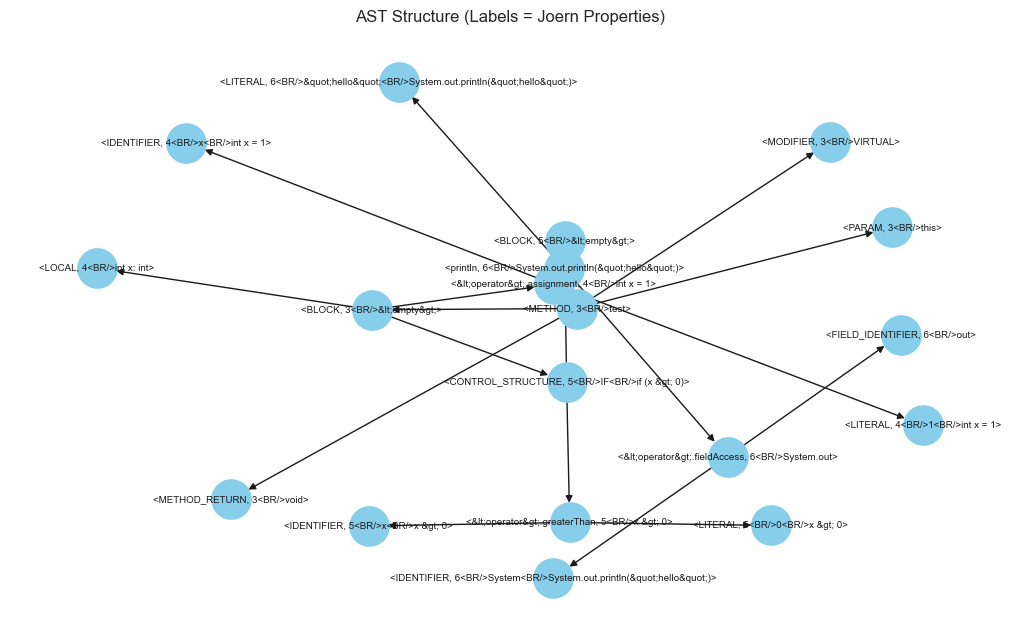

In [64]:
# --- SECTION 11: AST STRUCTURAL VERIFICATION ---
display(HTML("<hr><h1>Section 11: AST Structural Integrity Test</h1>"))

import sys
import os
sys.path.append(os.path.abspath("..")) # Ensure absolute path to project root

from spectral_code.graph.joern_graph import JoernGraphBuilder

builder = JoernGraphBuilder()
test_code = """
void test() {
    int x = 1;
    if (x > 0) {
        System.out.println("hello");
    }
}
"""

try:
    g_all = builder.build_all(test_code)
    ast = g_all.get('ast')
    
    if ast is None or ast.number_of_nodes() == 0:
        print("[-] AST generation failed (empty graph). Check if Joern is installed at C:\\joern-cli")
    else:
        print(f"[+] Nodes: {ast.number_of_nodes()}")
        print(f"[+] Edges: {ast.number_of_edges()}")
        
        # Print nodes and edges
        print("\n[+] Sample Nodes and their Labels:")
        for node, data in list(ast.nodes(data=True))[:10]:
            print(f"  {node}: {data}")

        # Plot this small AST
        plt.figure(figsize=(10, 6))
        pos = nx.spring_layout(ast, seed=42)
        
        # Extract labels for visualization
        labels = {n: d.get('label', n) for n, d in ast.nodes(data=True)}
            
        nx.draw(ast, pos, with_labels=True, labels=labels, 
                node_size=800, node_color="skyblue", font_size=7, arrows=True)
        plt.title("AST Structure (Labels = Joern Properties)")
        plt.show()

except Exception as e:
    print(f"[-] Error: {e}")
    import traceback
    traceback.print_exc()


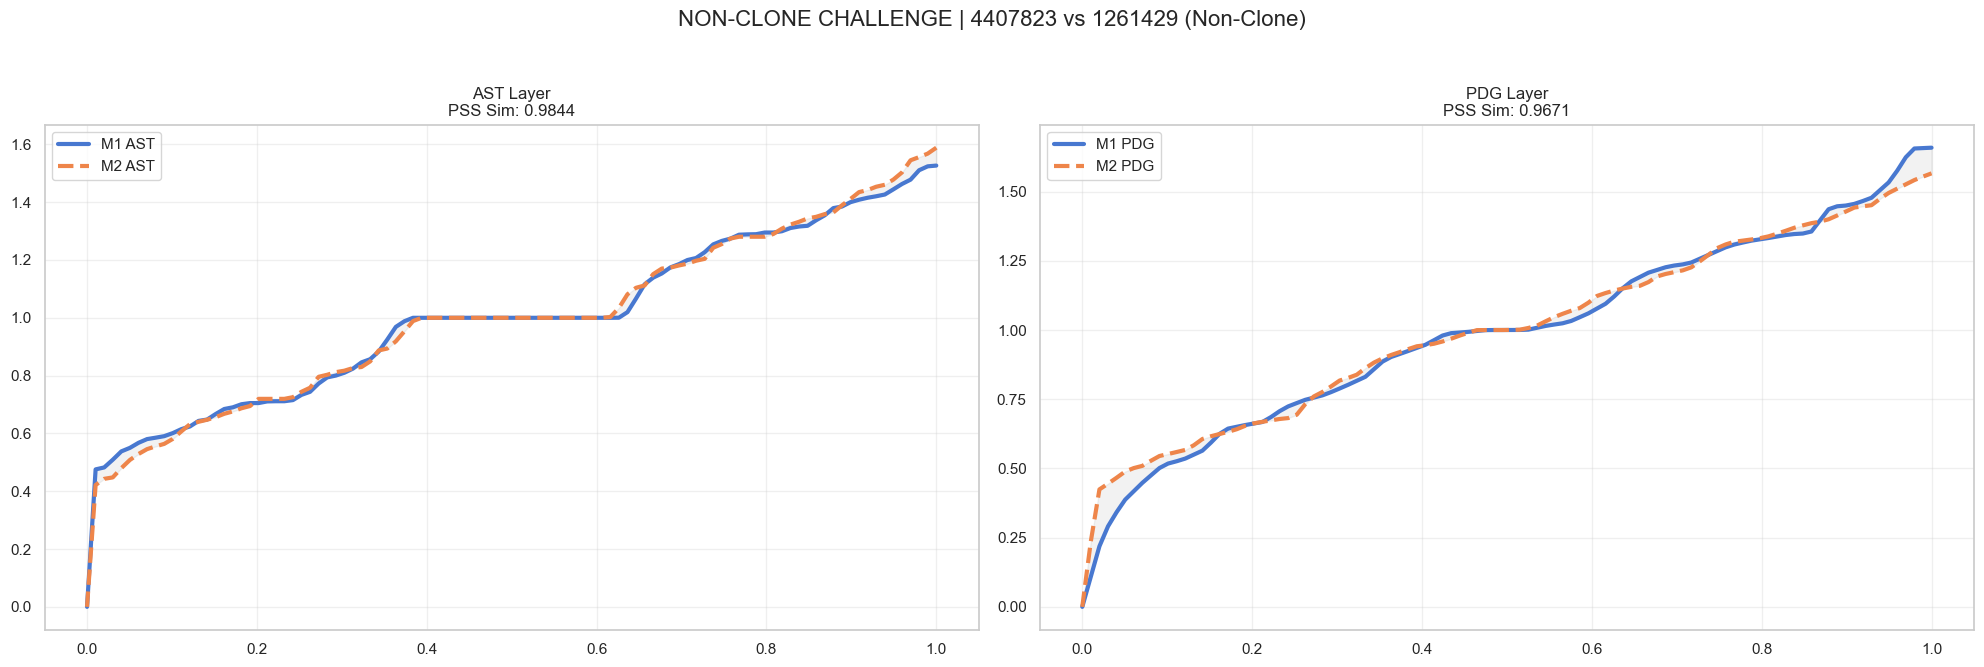

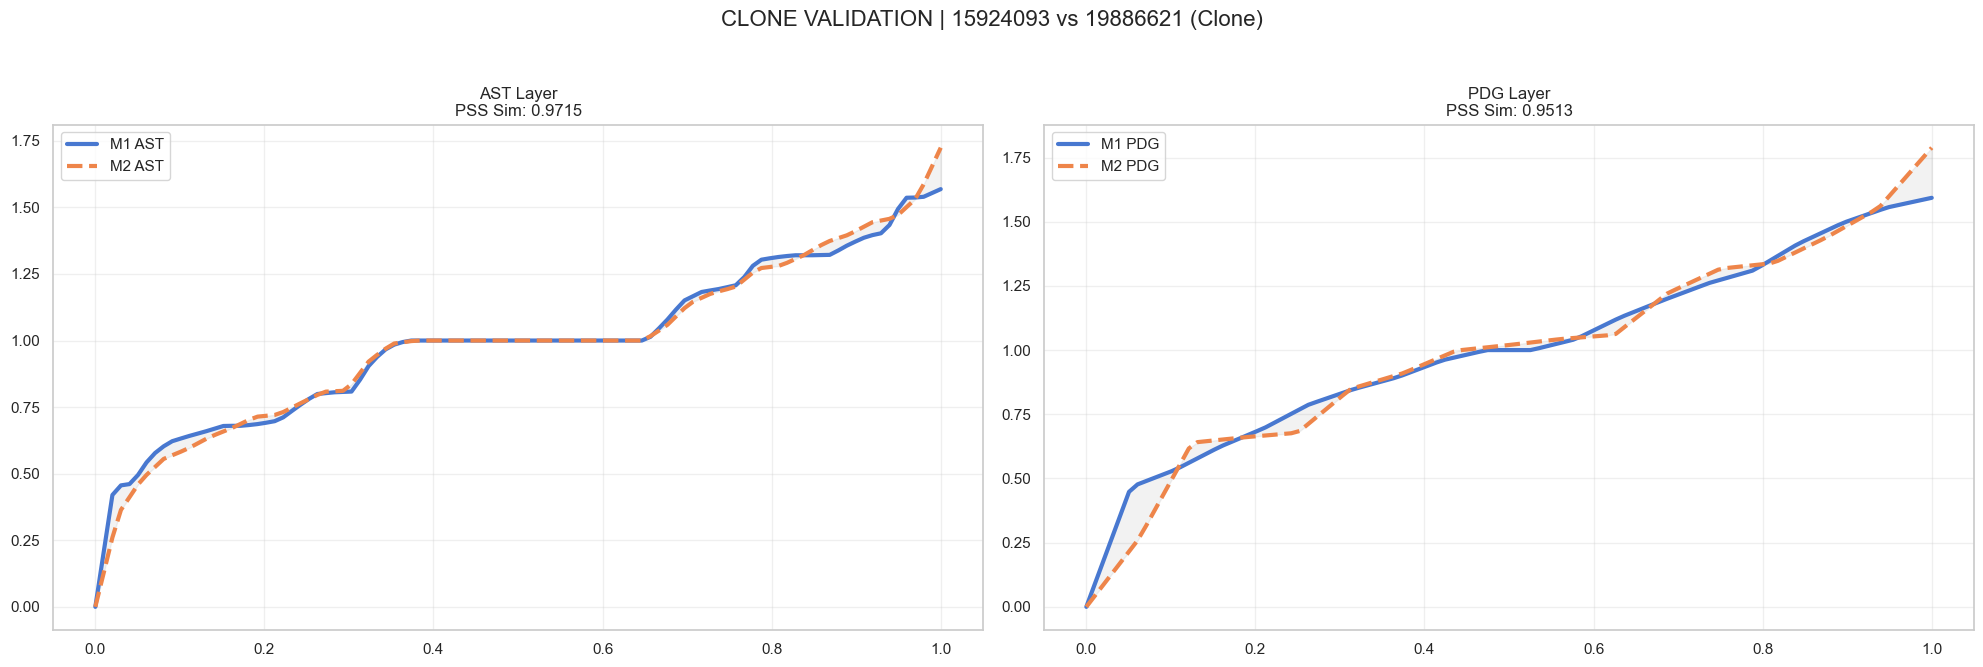

In [65]:
# --- SECTION 12: LAYER BATTLE (AST vs PDG) ---
display(HTML("<hr><h1>Section 12: Layer Battle - Does PDG Discriminate Better?</h1>"))

def compare_layers_spectrum(pair_row, title_prefix=""):
    id1 = str(int(float(pair_row['id1'])))
    id2 = str(int(float(pair_row['id2'])))
    label = "Clone" if pair_row['label'] == 1 else "Non-Clone"
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    
    for i, layer in enumerate(['ast', 'pdg']):
        ax = axes[i]
        g1 = graph_db.get(id1, {}).get(layer)
        g2 = graph_db.get(id2, {}).get(layer)
        
        if g1 and g2 and g1.number_of_nodes() > 0 and g2.number_of_nodes() > 0:
            ev1 = get_ast_spectral_signature(g1) # This function works for any DiGraph
            ev2 = get_ast_spectral_signature(g2)
            pss = pss_interpolation(ev1, ev2)
            
            x_axis = np.linspace(0, 1, 100)
            ax.plot(x_axis, resample(ev1), label=f'M1 {layer.upper()}', linewidth=3)
            ax.plot(x_axis, resample(ev2), label=f'M2 {layer.upper()}', linewidth=3, linestyle='--')
            ax.fill_between(x_axis, resample(ev1), resample(ev2), color='gray', alpha=0.1)
            ax.set_title(f"{layer.upper()} Layer\nPSS Sim: {pss:.4f}")
            ax.legend()
        else:
            ax.text(0.5, 0.5, f"{layer.upper()} Data Missing", ha='center')
        ax.grid(True, alpha=0.3)
        
    plt.suptitle(f"{title_prefix} | {id1} vs {id2} ({label})", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run for the False Positive case (where AST failed)
if tn_sample is not None:
    compare_layers_spectrum(tn_sample, "NON-CLONE CHALLENGE")

# Run for the True Positive case
if tp_sample is not None:
    compare_layers_spectrum(tp_sample, "CLONE VALIDATION")


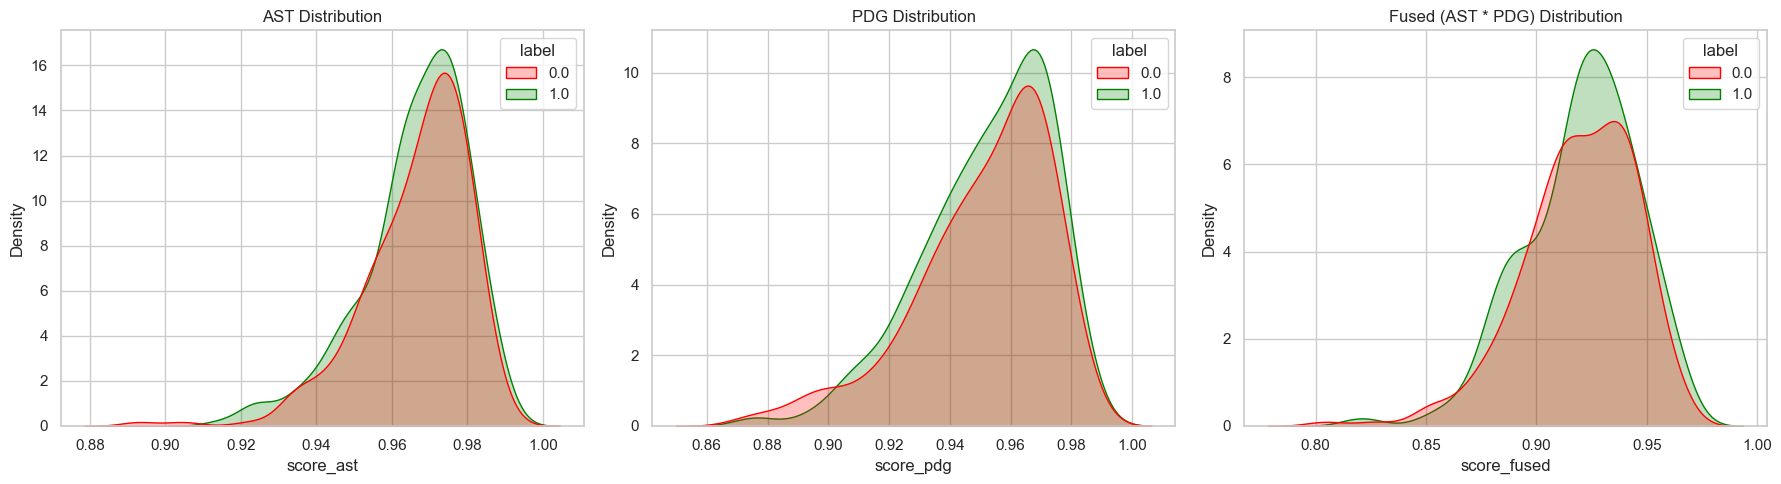

In [66]:
# --- SECTION 13: FUSION STRATEGY (AST + PDG) ---
display(HTML("<hr><h1>Section 13: Fusion Strategy Analysis (AST + PDG)</h1>"))

def compute_fusion_stats(sample_size=500):
    results_fused = []
    # Use a random sample from the main dataframe
    sub_df = df_sim.sample(min(sample_size, len(df_sim)))
    
    for _, row in sub_df.iterrows():
        id1, id2 = str(int(float(row['id1']))), str(int(float(row['id2'])))
        
        # Get graphs from DB
        g_ast1 = graph_db.get(id1, {}).get('ast')
        g_ast2 = graph_db.get(id2, {}).get('ast')
        g_pdg1 = graph_db.get(id1, {}).get('pdg')
        g_pdg2 = graph_db.get(id2, {}).get('pdg')
        
        if all([g_ast1, g_ast2, g_pdg1, g_pdg2]):
            # 1. AST PSS
            ev_ast1 = get_ast_spectral_signature(g_ast1)
            ev_ast2 = get_ast_spectral_signature(g_ast2)
            score_ast = pss_interpolation(ev_ast1, ev_ast2)
            
            # 2. PDG PSS
            ev_pdg1 = get_ast_spectral_signature(g_pdg1)
            ev_pdg2 = get_ast_spectral_signature(g_pdg2)
            score_pdg = pss_interpolation(ev_pdg1, ev_pdg2)
            
            # 3. Fusion (Multiplicative)
            # This requires BOTH to be similar. Good for filtering False Positives.
            score_fused = score_ast * score_pdg
            
            results_fused.append({
                "label": row['label'],
                "score_ast": score_ast,
                "score_pdg": score_pdg,
                "score_fused": score_fused
            })
            
    return pd.DataFrame(results_fused)

df_f = compute_fusion_stats(500)

if not df_f.empty:
    # Calculate Gaps
    gap_ast = df_f[df_f['label']==1]['score_ast'].mean() - df_f[df_f['label']==0]['score_ast'].mean()
    gap_pdg = df_f[df_f['label']==1]['score_pdg'].mean() - df_f[df_f['label']==0]['score_pdg'].mean()
    gap_fused = df_f[df_f['label']==1]['score_fused'].mean() - df_f[df_f['label']==0]['score_fused'].mean()
    
    display(HTML(f"""
    <div style='display: flex; gap: 20px;'>
        <div style='padding:10px; border:1px solid #ccc; background:#e1f5fe'><b>AST Gap:</b> {gap_ast:.4f}</div>
        <div style='padding:10px; border:1px solid #ccc; background:#e8f5e9'><b>PDG Gap:</b> {gap_pdg:.4f}</div>
        <div style='padding:10px; border:1px solid #ccc; background:#fff3e0'><b>Fused Gap:</b> {gap_fused:.4f}</div>
    </div>
    """))
    
    # Plot Distribution Comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.kdeplot(data=df_f, x="score_ast", hue="label", fill=True, ax=axes[0], palette={1:"green", 0:"red"})
    axes[0].set_title("AST Distribution")
    
    sns.kdeplot(data=df_f, x="score_pdg", hue="label", fill=True, ax=axes[1], palette={1:"green", 0:"red"})
    axes[1].set_title("PDG Distribution")
    
    sns.kdeplot(data=df_f, x="score_fused", hue="label", fill=True, ax=axes[2], palette={1:"green", 0:"red"})
    axes[2].set_title("Fused (AST * PDG) Distribution")
    
    plt.tight_layout()
    plt.show()
else:
    print("[-] Missing graph data for fusion calculation.")


[+] AST Inspection for 23630686: 59 nodes, 58 edges
[+] AST Inspection for 14537899: 59 nodes, 58 edges


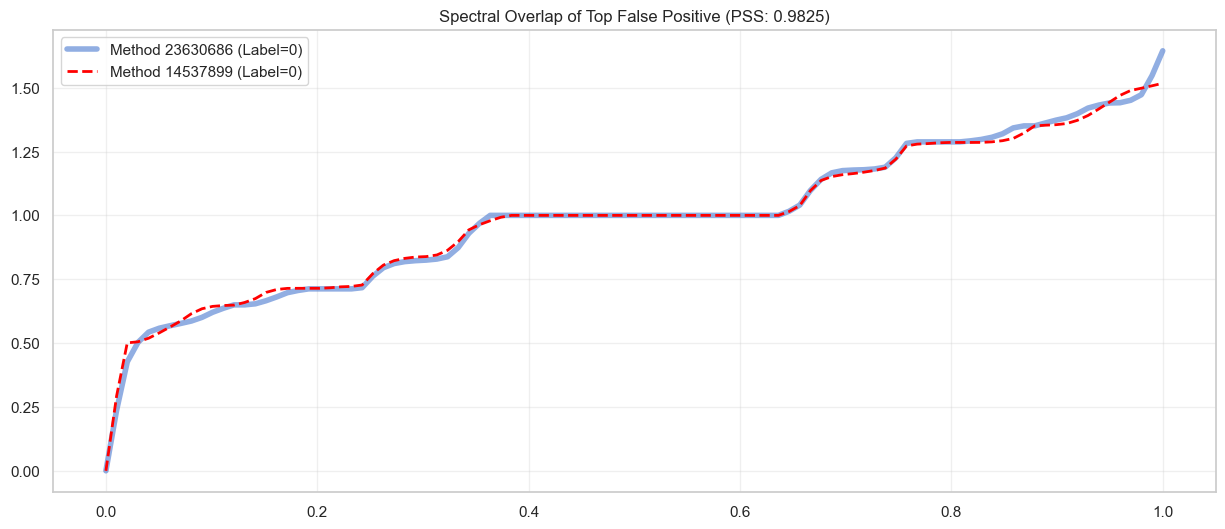

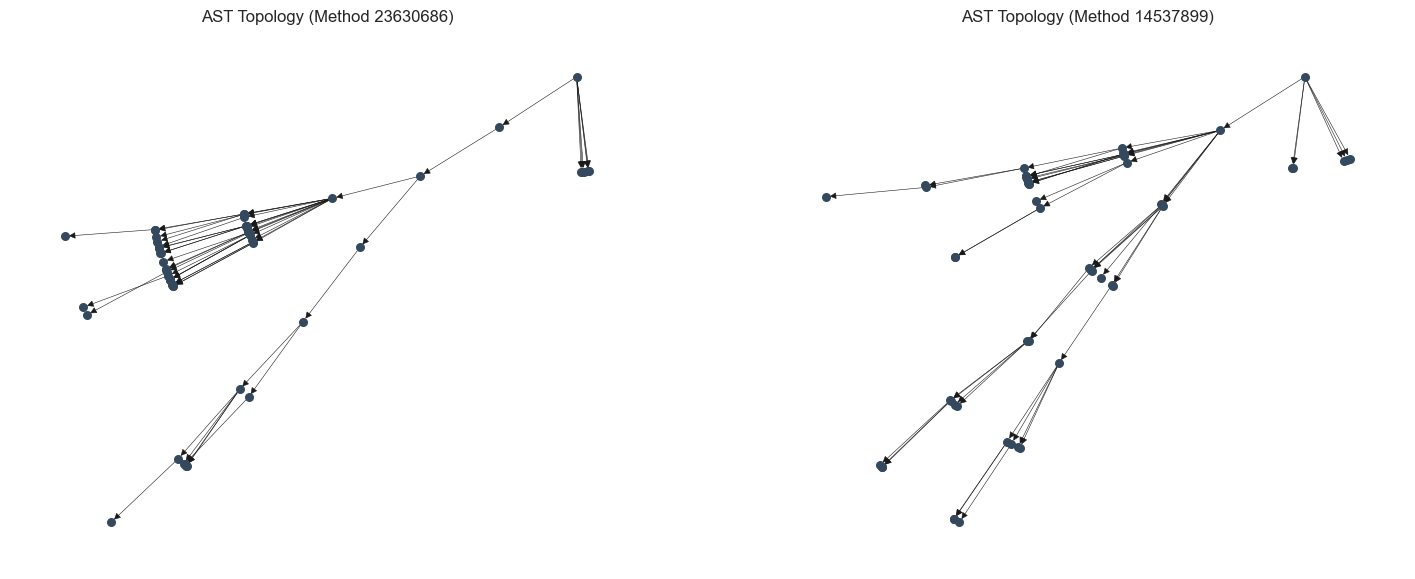

In [67]:
# --- SECTION 14: DEEP DIVE INTO TOP AST FALSE POSITIVE ---
display(HTML("<hr><h1>Section 14: Forensic Analysis of Top AST False Positive</h1>"))

# 1. Find the most "misleading" Non-Clone (Label 0 with highest AST score)
if 'df_sim' in locals() and not df_sim.empty:
    fp_candidates = df_sim[df_sim['label'] == 0].sort_values('pss_ast', ascending=False)
    top_fp = fp_candidates.iloc[0]
    
    id1 = str(int(float(top_fp['id1'])))
    id2 = str(int(float(top_fp['id2'])))
    ast_score = top_fp['pss_ast']
    
    display(HTML(f"<h3>Top False Positive Pair | ID: {id1} vs {id2} | AST Similarity: <span style='color:red'>{ast_score:.4f}</span></h3>"))
    
    # Reuse visualize_triple_view logic but focused on AST deep dive
    c1 = source_code_map.get(id1, "Source not found")
    c2 = source_code_map.get(id2, "Source not found")
    
    # Show source code
    code_html = f"""
    <div style="display: flex; gap: 10px; margin-bottom: 20px;">
        <div style="flex: 1; max-height: 250px; overflow: auto; border: 1px solid #ddd; padding: 5px; background: #fafafa;">
            <b>Method {id1}</b>
            <pre style="font-size: 10px;">{c1.replace('<','&lt;').replace('>','&gt;')}</pre>
        </div>
        <div style="flex: 1; max-height: 250px; overflow: auto; border: 1px solid #ddd; padding: 5px; background: #fafafa;">
            <b>Method {id2}</b>
            <pre style="font-size: 10px;">{c2.replace('<','&lt;').replace('>','&gt;')}</pre>
        </div>
    </div>
    """
    display(HTML(code_html))
    
    # Inspect AST Nodes directly for these IDs
    g1 = graph_db.get(id1, {}).get('ast')
    g2 = graph_db.get(id2, {}).get('ast')
    
    if g1 and g2:
        print(f"[+] AST Inspection for {id1}: {g1.number_of_nodes()} nodes, {g1.number_of_edges()} edges")
        print(f"[+] AST Inspection for {id2}: {g2.number_of_nodes()} nodes, {g2.number_of_edges()} edges")
        
        # Plot spectrum explicitly showing the overlap
        ev1 = get_ast_spectral_signature(g1)
        ev2 = get_ast_spectral_signature(g2)
        
        plt.figure(figsize=(15, 6))
        x = np.linspace(0, 1, 100)
        plt.plot(x, resample(ev1), label=f'Method {id1} (Label=0)', linewidth=4, alpha=0.6)
        plt.plot(x, resample(ev2), label=f'Method {id2} (Label=0)', linewidth=2, linestyle='--', color='red')
        plt.title(f"Spectral Overlap of Top False Positive (PSS: {ast_score:.4f})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Draw Graphs for visual structural confirmation
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for i, (g, mid) in enumerate([(g1, id1), (g2, id2)]):
            pos = nx.kamada_kawai_layout(g)
            nx.draw(g, pos, ax=axes[i], node_size=30, node_color="#34495e", width=0.4, arrows=True, with_labels=False)
            axes[i].set_title(f"AST Topology (Method {mid})")
        plt.show()
    else:
        print("[-] Graphs for these IDs not found in graph_db.")
else:
    print("[-] df_sim is empty.")


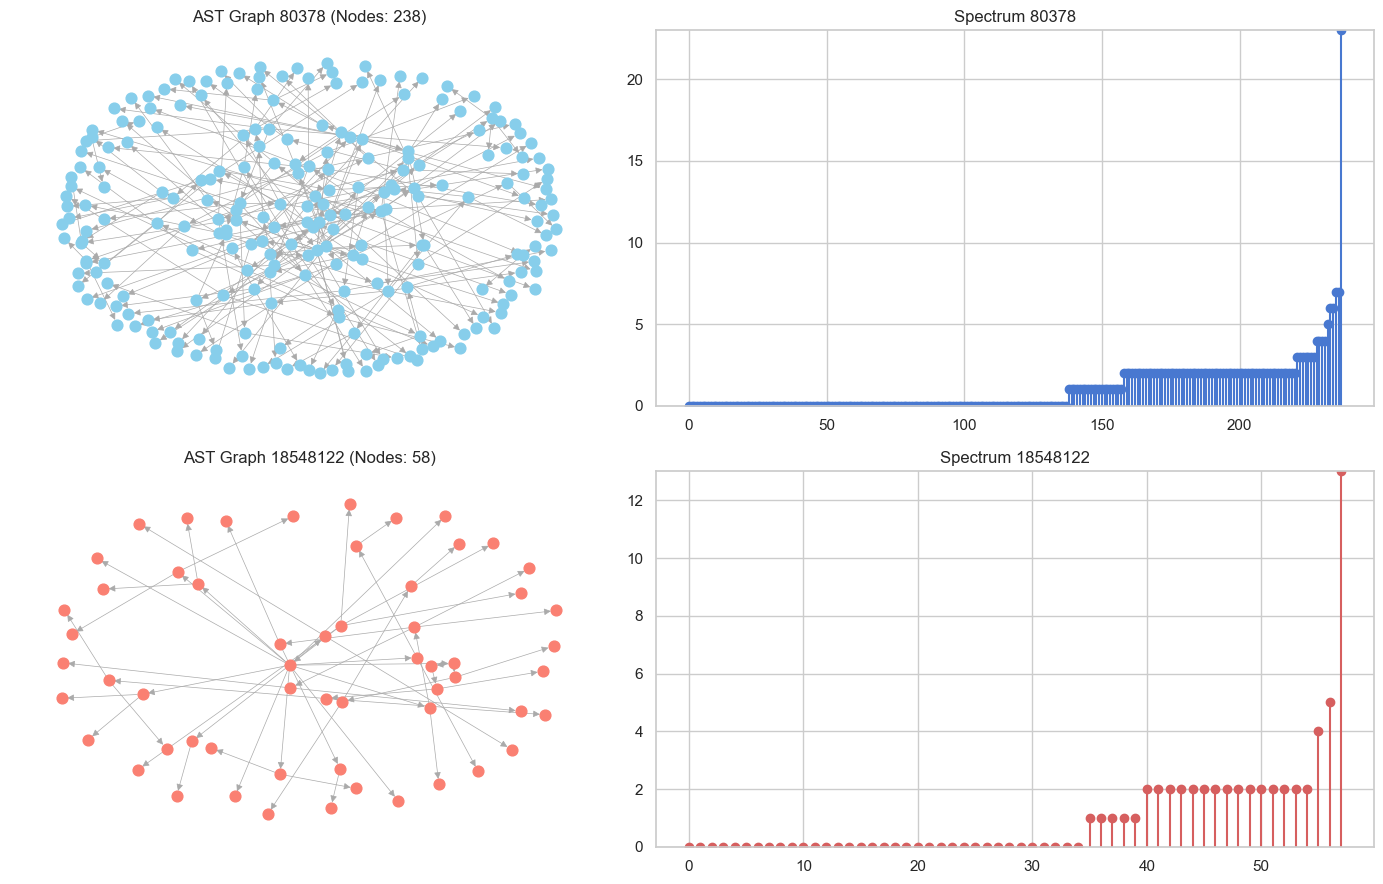

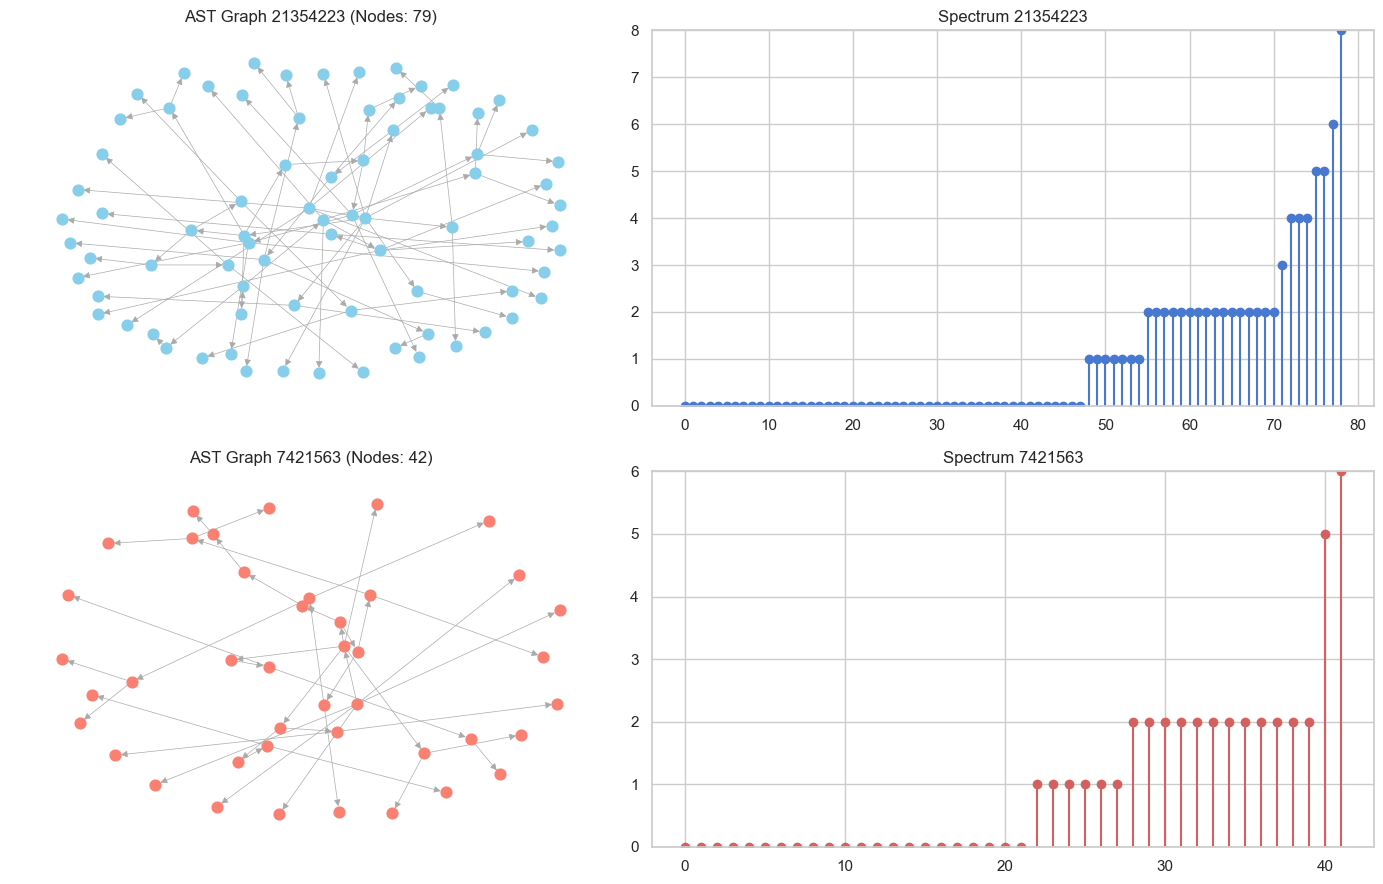

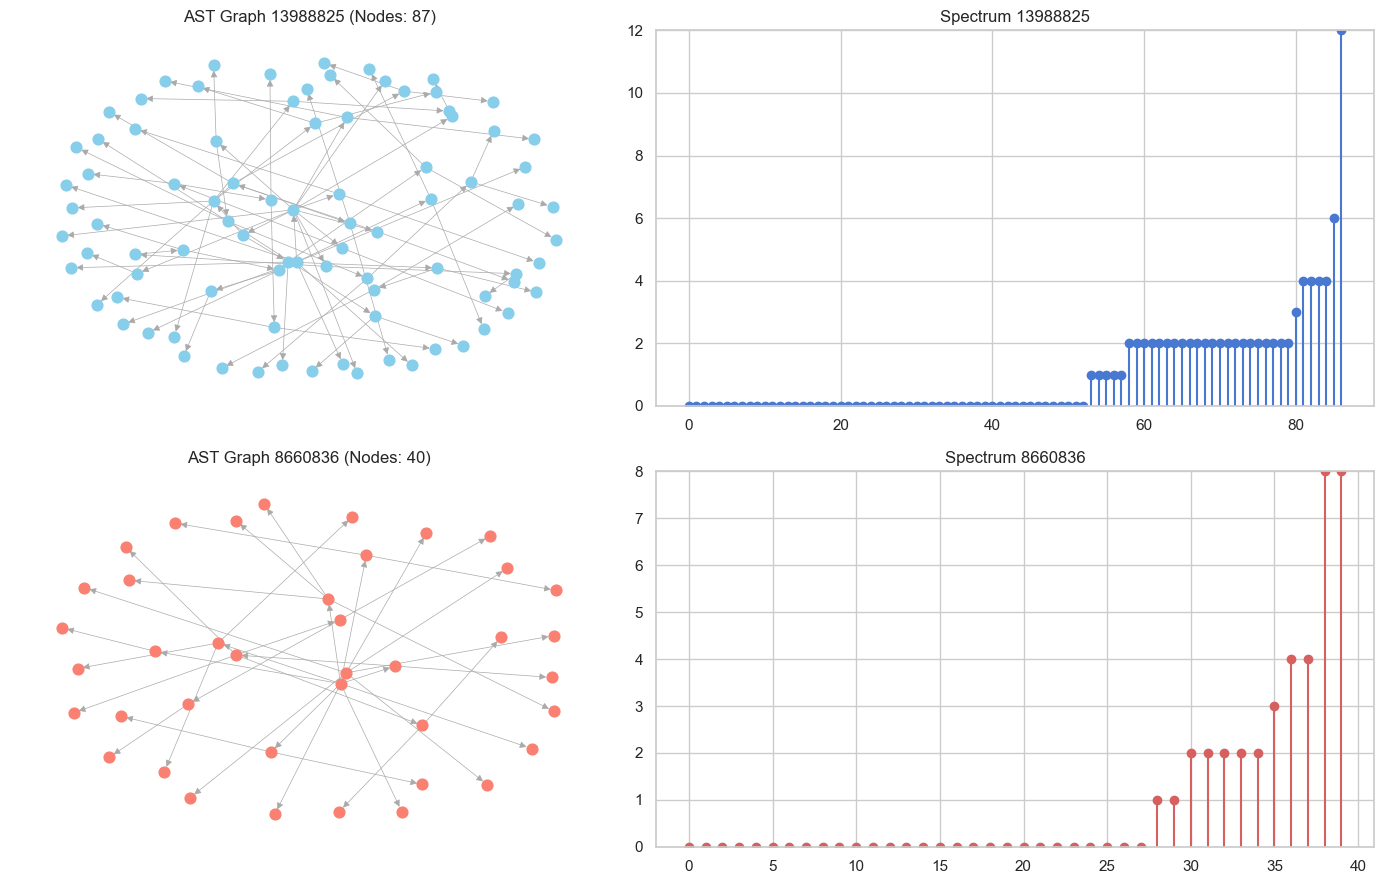

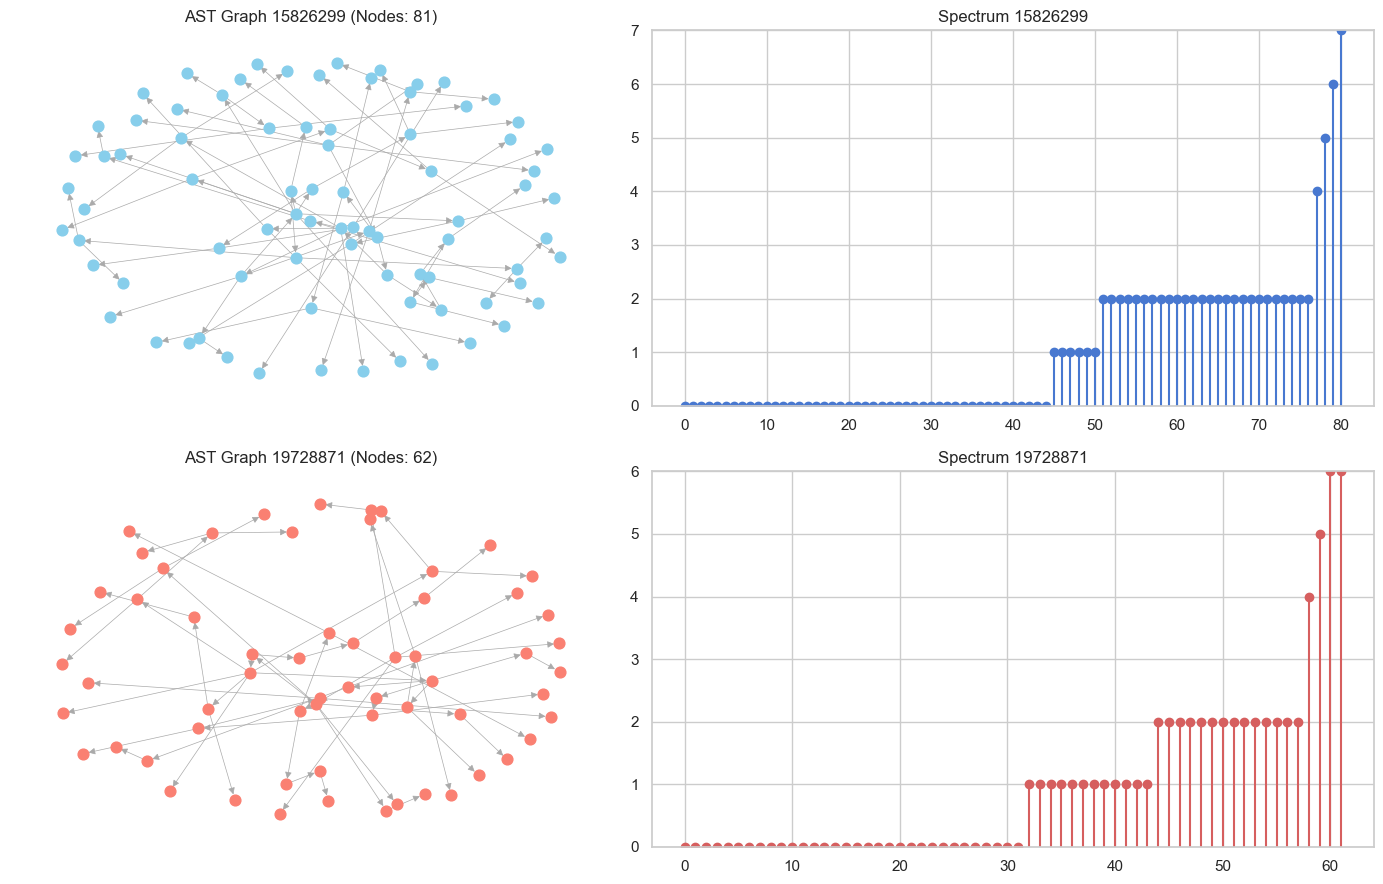

In [68]:
# --- SECTION 5: AST Visual Dashboard (Code + Graph + Spectrum) ---
import sys
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

display(HTML("<h1>Section 5: AST Visual Dashboard</h1>"))

# Tools Setup
builder = JoernGraphBuilder(repr_type="ast")
pss_metric = PSSSimilarity()
ged_metric = GEDSimilarity(timeout=10) # Shorter timeout for live dashboard
analyzer = create_spectral_analyzer("laplacian", "dense", k=24, solver_kwargs={}, spectral_kwargs={})

def get_clean_spectrum(g):
    ev, _ = analyzer.analyze(g)
    # Filter out near-zero noise. Values sorted ascending.
    nz = np.nonzero(np.round(ev, 8))[0]
    return ev[:nz[-1]+1] if len(nz) > 0 else np.array([0.0])

for id1, id2, label, desc in comparison_pairs:
    display(HTML(f"<div style='background: #f0f0f0; padding: 10px; border-left: 5px solid {'#2ecc71' if label==1 else '#e74c3c'}; margin-top: 20px;'>"
                 f"<h3>{desc} (ID: {id1} vs {id2})</h3></div>"))
    
    code1, code2 = code_samples[id1], code_samples[id2]
    g1, g2 = builder.build(code1), builder.build(code2)
    ev1 = get_clean_spectrum(g1)
    ev2 = get_clean_spectrum(g2)
    
    # Calculate Similarities
    pss_val = pss_metric.compute(ev1, ev2)
    ged_val = ged_metric.compute_normalized(g1, g2)
    
    # Visualization: Code Snippets & Scores
    # Side-by-Side Code (HTML)
    code_html = f"""
    <div style="display: flex; gap: 10px; margin-bottom: 20px;">
        <div style="flex: 1; border: 1px solid #ddd; border-radius: 5px;">
            <div style="background: #eee; padding: 5px; font-weight: bold;">Code {id1}</div>
            <pre style="font-size: 10px; height: 180px; overflow: auto; padding: 10px; margin: 0;">{code1.replace('<','&lt;')}</pre>
        </div>
        <div style="flex: 1; border: 1px solid #ddd; border-radius: 5px;">
            <div style="background: #eee; padding: 5px; font-weight: bold;">Code {id2}</div>
            <pre style="font-size: 10px; height: 180px; overflow: auto; padding: 10px; margin: 0;">{code2.replace('<','&lt;')}</pre>
        </div>
    </div>
    <div style="display: flex; gap: 10px; margin-bottom: 20px;">
        <div style="flex: 1; background: #e8f5e9; padding: 10px; border-radius: 5px; text-align: center; border: 1px solid #c8e6c9;">
            <strong>PSS (Spectral): <span style="color: #2e7d32; font-size: 1.2em;">{pss_val:.4f}</span></strong>
        </div>
        <div style="flex: 1; background: #e3f2fd; padding: 10px; border-radius: 5px; text-align: center; border: 1px solid #bbdefb;">
            <strong>GED (Structural): <span style="color: #1565c0; font-size: 1.2em;">{ged_val:.4f}</span></strong>
        </div>
    </div>
    """
    display(HTML(code_html))

    # Visualization: Plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), gridspec_kw={'width_ratios': [1, 1.2]})
    
    # AST 1
    pos1 = nx.spring_layout(g1, seed=42, k=0.3)
    nx.draw(g1, pos1, ax=axes[0, 0], with_labels=False, node_size=60, node_color="skyblue", edge_color="#aaa", width=0.5)
    axes[0, 0].set_title(f"AST Graph {id1} (Nodes: {len(g1.nodes)})")
    
    # Spectrum 1
    axes[0, 1].stem(ev1, basefmt=" ", linefmt='b-', markerfmt='bo')
    axes[0, 1].set_title(f"Spectrum {id1}")
    axes[0, 1].set_ylim(0, max(max(ev1), 5) if len(ev1)>0 else 5)

    # AST 2
    pos2 = nx.spring_layout(g2, seed=42, k=0.3)
    nx.draw(g2, pos2, ax=axes[1, 0], with_labels=False, node_size=60, node_color="salmon", edge_color="#aaa", width=0.5)
    axes[1, 0].set_title(f"AST Graph {id2} (Nodes: {len(g2.nodes)})")
    
    # Spectrum 2
    axes[1, 1].stem(ev2, basefmt=" ", linefmt='r-', markerfmt='ro')
    axes[1, 1].set_title(f"Spectrum {id2}")
    axes[1, 1].set_ylim(0, max(max(ev2), 5) if len(ev2)>0 else 5)
    
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")


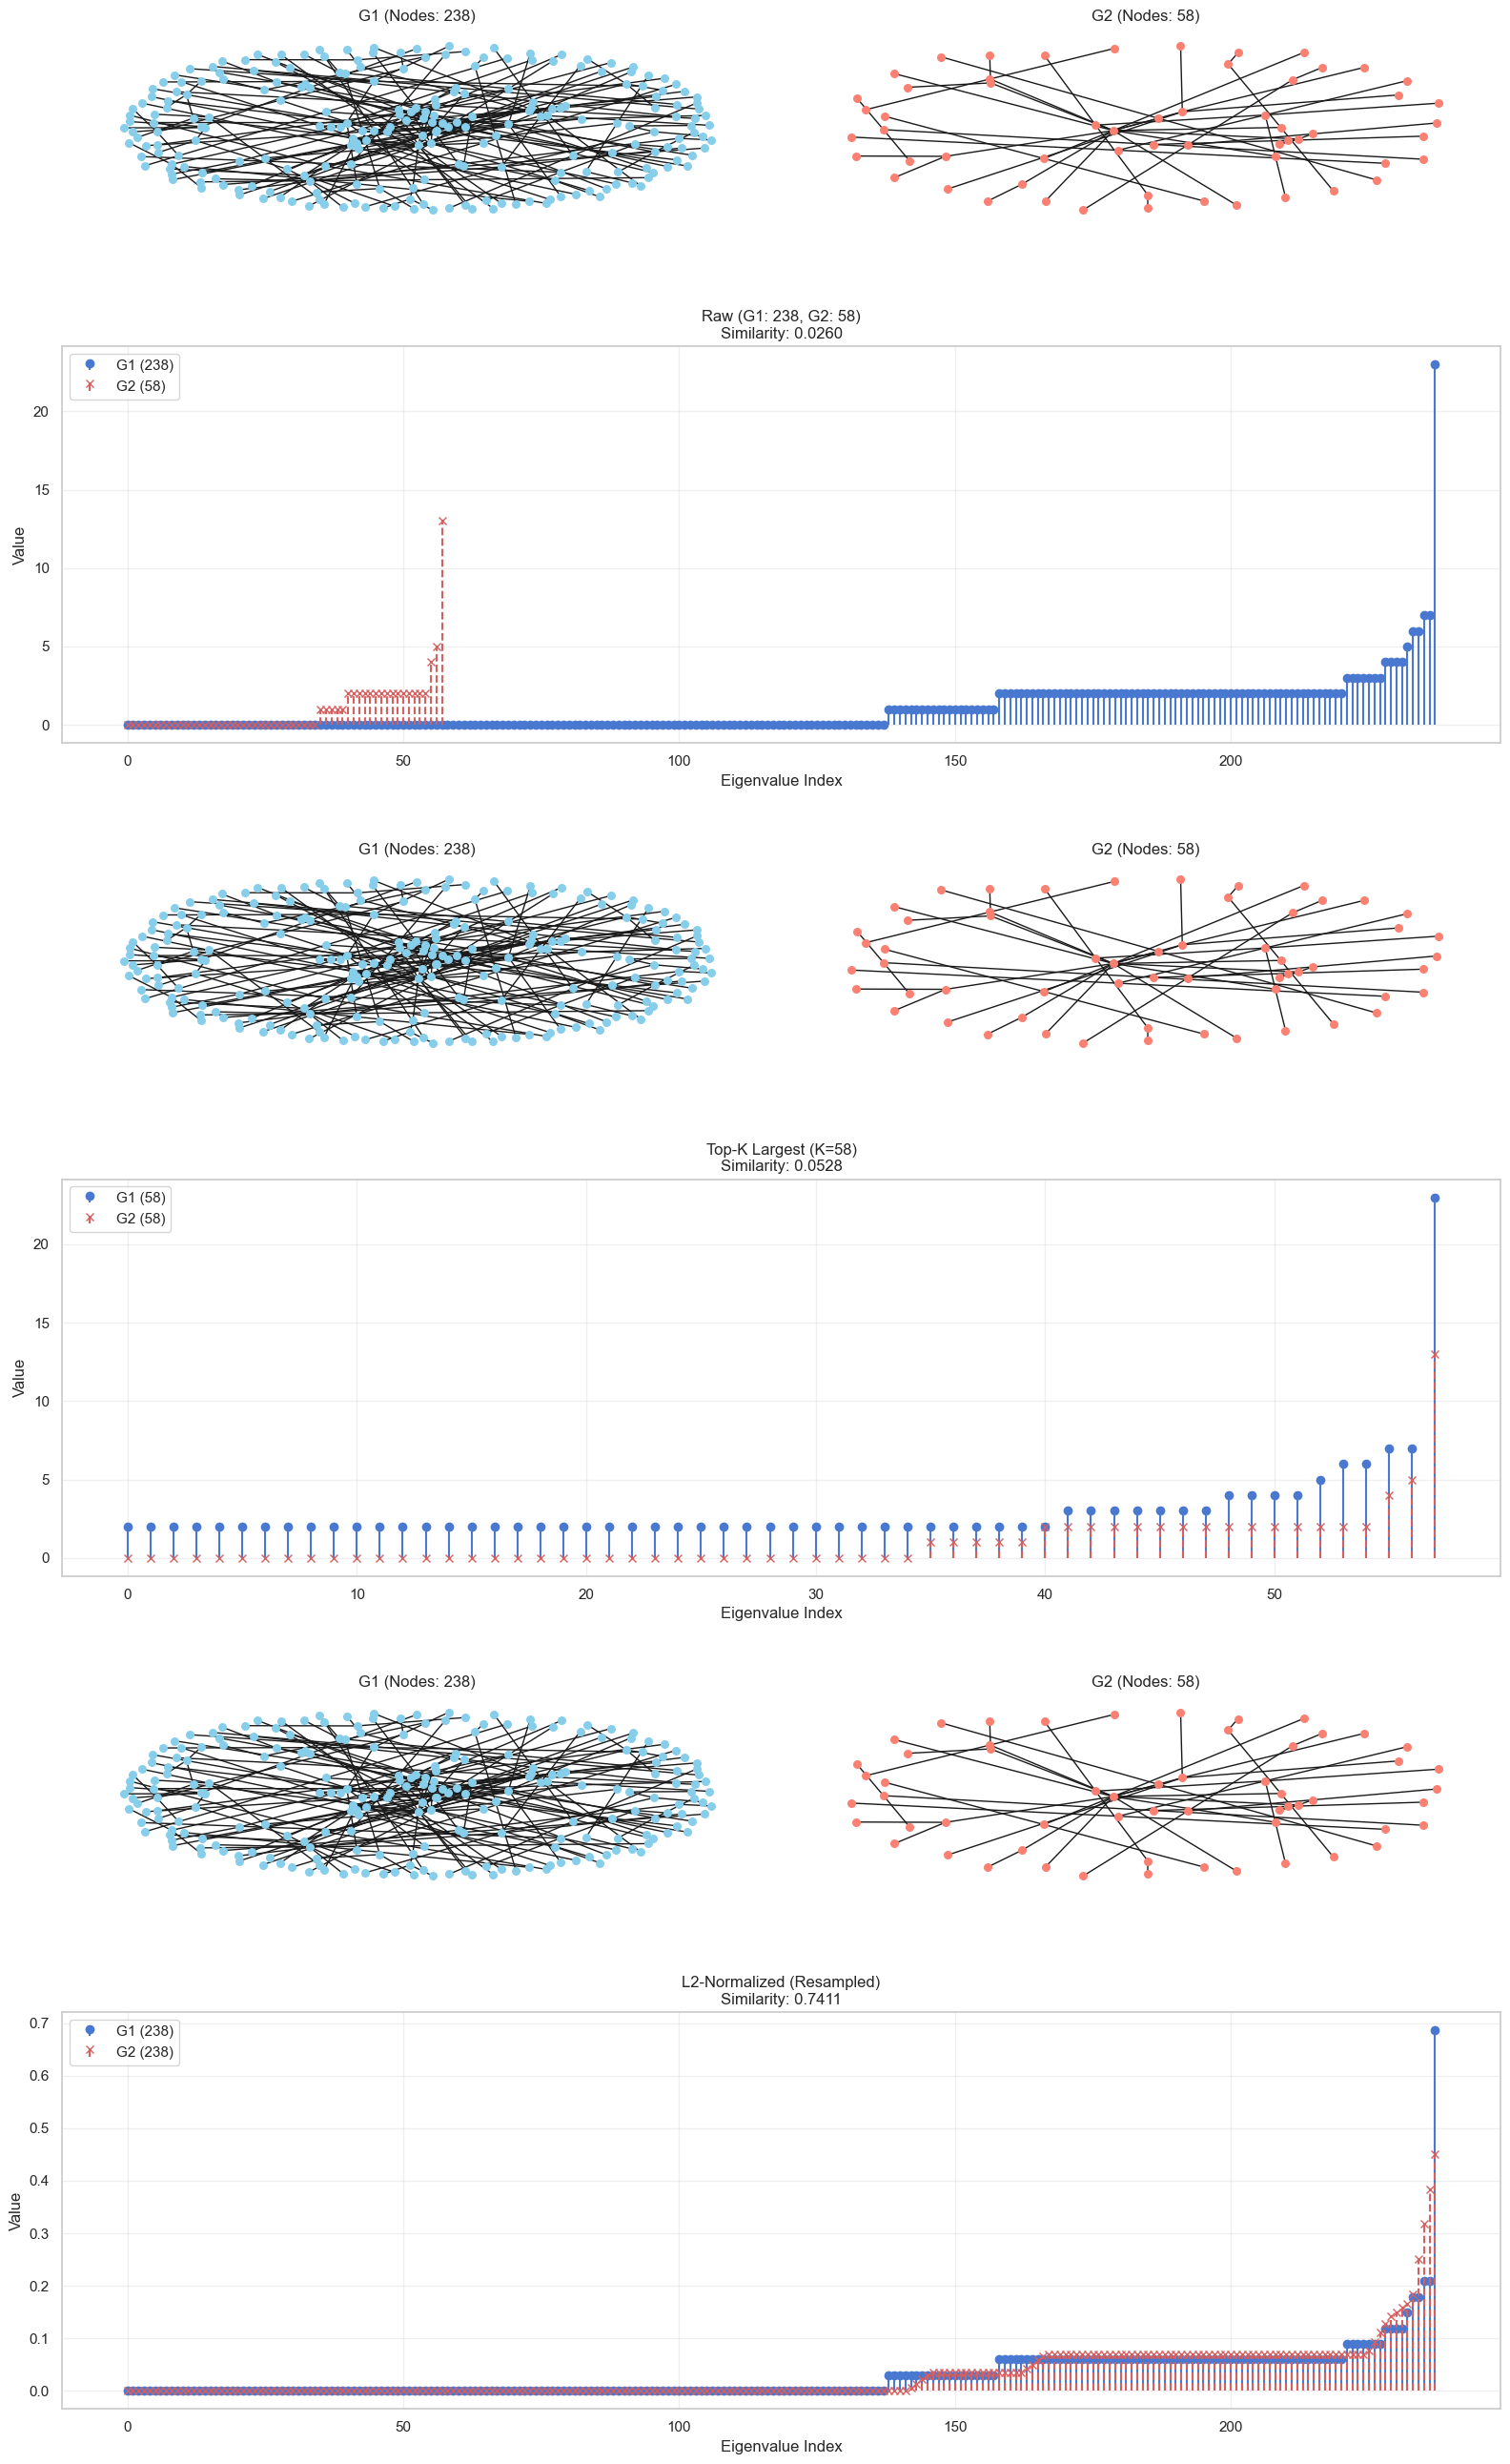

In [69]:
# --- SECTION 6: Spectral Variants Dashboard (Raw, Top-K Largest, Normalized) ---
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

display(HTML("<h1>Section 6: Comparison of Spectral Variants</h1>"))

def compute_detailed_variant(ev1, ev2, mode='norm'):
    # 1. Strip padding
    def strip(ev):
        nz = np.nonzero(np.round(ev, 10))[0]
        return ev[:nz[-1] + 1] if len(nz) > 0 else np.array([0.0])
    
    v1_raw = strip(ev1)
    v2_raw = strip(ev2)
    
    if len(v1_raw) == 0 or len(v2_raw) == 0: return 0.0, None, None, ""
    
    title = ""
    if mode == 'raw':
        # User specified: 238 of G1 vs 58 of G2
        v1_final = v1_raw[:238]
        v2_final = v2_raw[:58]
        
        # For similarity calculation, zero-pad shorter to match longer
        max_len = max(len(v1_final), len(v2_final))
        v1_p = np.pad(v1_final, (0, max_len - len(v1_final)))
        v2_p = np.pad(v2_final, (0, max_len - len(v2_final)))
        dist = np.linalg.norm(v1_p - v2_p)
        title = f"Raw (G1: {len(v1_final)}, G2: {len(v2_final)})"
        
    elif mode == 'topk':
        # User specified: 58 largest of G1 vs 58 largest of G2
        # Use np.sort to get values in ascending order, then take last 58
        v1_sort = np.sort(v1_raw)
        v2_sort = np.sort(v2_raw)
        
        v1_top = v1_sort[-58:] if len(v1_sort) >= 58 else np.pad(v1_sort, (58-len(v1_sort), 0))
        v2_top = v2_sort[-58:] if len(v2_sort) >= 58 else np.pad(v2_sort, (58-len(v2_sort), 0))
        
        dist = np.linalg.norm(v1_top - v2_top)
        
        v1_final, v2_final = v1_top, v2_top
        title = f"Top-K Largest (K=58)"
        
    else: # mode == 'norm'
        # Resample as before
        max_len = max(len(v1_raw), len(v2_raw))
        v1_res = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(v1_raw)), v1_raw)
        v2_res = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(v2_raw)), v2_raw)
        
        v1_final = v1_res / (np.linalg.norm(v1_res) or 1.0)
        v2_final = v2_res / (np.linalg.norm(v2_res) or 1.0)
        dist = np.linalg.norm(v1_final - v2_final)
        title = "L2-Normalized (Resampled)"
        
    sim = 1.0 / (1.0 + dist)
    return sim, v1_final, v2_final, title

# Use the Logic Match pair
id1, id2 = "80378", "18548122"
code1, code2 = code_samples[id1], code_samples[id2]
g1, g2 = builder.build(code1), builder.build(code2)
ev1, _ = analyzer.analyze(g1)
ev2, _ = analyzer.analyze(g2)

variants = ['raw', 'topk', 'norm']
results = [compute_detailed_variant(ev1, ev2, mode=m) for m in variants]

# Dashboard Setup - Vertical layout
fig = plt.figure(figsize=(16, 26)) # Increased height to prevent cutoff
gs = fig.add_gridspec(6, 2, height_ratios=[1, 2, 1, 2, 1, 2]) 

for i, (sim, v1, v2, title) in enumerate(results):
    row_graph = i * 2
    row_spec = i * 2 + 1
    
    # Graphs
    ax_g1 = fig.add_subplot(gs[row_graph, 0])
    nx.draw(g1, nx.spring_layout(g1, seed=42), ax=ax_g1, node_size=30, node_color='skyblue', arrows=False)
    ax_g1.set_title(f"G1 (Nodes: {len(g1.nodes)})")
    
    ax_g2 = fig.add_subplot(gs[row_graph, 1])
    nx.draw(g2, nx.spring_layout(g2, seed=42), ax=ax_g2, node_size=30, node_color='salmon', arrows=False)
    ax_g2.set_title(f"G2 (Nodes: {len(g2.nodes)})")
    
    # Spectrum
    ax_spec = fig.add_subplot(gs[row_spec, :])
    
    ax_spec.stem(v1, linefmt='b-', markerfmt='bo', label=f'G1 ({len(v1)})', basefmt=" ")
    ax_spec.stem(v2, linefmt='r--', markerfmt='rx', label=f'G2 ({len(v2)})', basefmt=" ")
    
    ax_spec.set_title(f"{title}\nSimilarity: {sim:.4f}")
    ax_spec.set_xlabel("Eigenvalue Index")
    ax_spec.set_ylabel("Value")
    ax_spec.legend()
    ax_spec.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # Add space between subplots
plt.show()

# Display Code
display(HTML(f"""
<div style="display: flex; gap: 10px; margin-top: 20px;">
    <div style="flex: 1; border: 1px solid #ddd; padding: 10px;">
        <strong>Method 80378 (G1)</strong><br>
        <pre style="font-size: 9px; max-height: 200px; overflow: auto;">{code1.replace('<','&lt;')}</pre>
    </div>
    <div style="flex: 1; border: 1px solid #ddd; padding: 10px;">
        <strong>Method 18548122 (G2)</strong><br>
        <pre style="font-size: 9px; max-height: 200px; overflow: auto;">{code2.replace('<','&lt;')}</pre>
    </div>
</div>
"""))

[*] Analyzing 1000 pairs for distribution (Label 0 vs 1)...


100%|██████████| 1000/1000 [00:27<00:00, 36.90it/s]


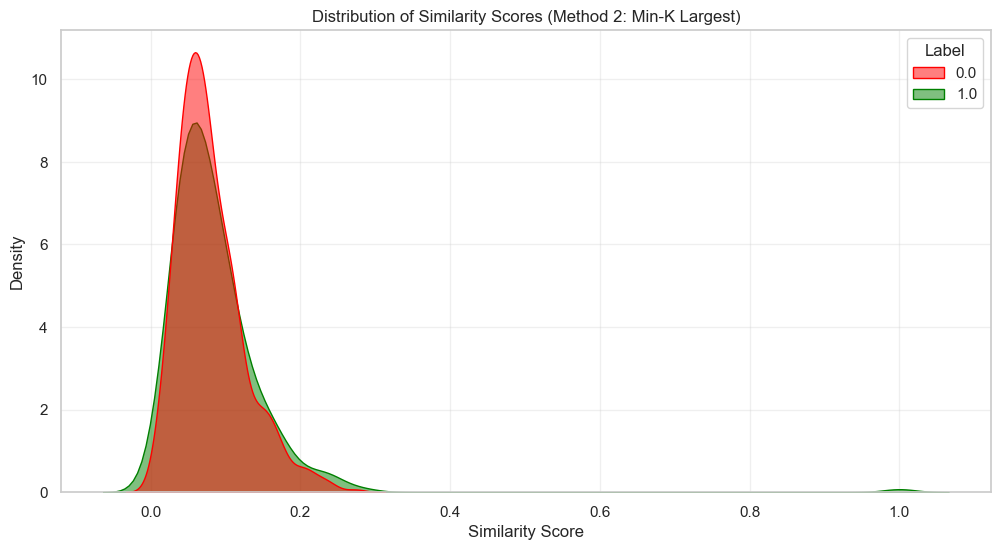


DISCRIMINABILITY STATS (N=1000):
[+] Non-Clones (0) Mean: 0.0799 (Std: 0.0446)
[+] Clones (1)     Mean: 0.0862 (Std: 0.0759)
[+] Score Gap:       0.0062


In [72]:
# --- SECTION 7: Distribution Analysis for Method 2 (Dynamic Top-K: Min Nodes) ---
import seaborn as sns
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

display(HTML("<h1>Section 7: Score Distribution (Method 2: Min-K Largest)</h1>"))

# We'll take a sample of 1000 pairs (if available) for a representative distribution
if not df_sim.empty:
    sample_size = 1000 
    df_sample = df_sim.sample(min(sample_size, len(df_sim)), random_state=42)
    
    method2_scores = []
    labels = []
    
    print(f"[*] Analyzing {len(df_sample)} pairs for distribution (Label 0 vs 1)...")
    
    # Method 2 logic
    def get_mink_similarity(ev1, ev2):
        if ev1 is None or ev2 is None or len(ev1) == 0 or len(ev2) == 0:
            return 0.0
            
        def strip(ev):
            nz = np.nonzero(np.round(ev, 10))[0]
            return ev[:nz[-1] + 1] if len(nz) > 0 else np.array([0.0])
        
        v1_s = strip(ev1)
        v2_s = strip(ev2)
        
        # Dynamic K: Use the smaller count of nodes between the two
        K = min(len(v1_s), len(v2_s))
        if K == 0: return 0.0
        
        v1_top = np.sort(v1_s)[-K:]
        v2_top = np.sort(v2_s)[-K:]
        
        dist = np.linalg.norm(v1_top - v2_top)
        return 1.0 / (1.0 + dist)

    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        id1, id2 = str(int(float(row['id1']))), str(int(float(row['id2'])))
        label = row['label']
        
        # Optimization: Use graph_db if pre-built graphs exist (much faster than Joern)
        if id1 in graph_db and id2 in graph_db:
            g1 = graph_db[id1].get('ast')
            g2 = graph_db[id2].get('ast')
            
            if g1 and g2:
                # Get eigenvalues using the already initialized analyzer
                ev1, _ = analyzer.analyze(g1)
                ev2, _ = analyzer.analyze(g2)
                sim = get_mink_similarity(ev1, ev2)
                method2_scores.append(sim)
                labels.append(label)
                continue

        # Fallback to Joern if not in DB
        code1 = source_code_map.get(id1)
        code2 = source_code_map.get(id2)
        if code1 and code2:
            try:
                g1 = builder.build(code1)
                g2 = builder.build(code2)
                ev1_raw, _ = analyzer.analyze(g1)
                ev2_raw, _ = analyzer.analyze(g2)
                sim = get_mink_similarity(ev1_raw, ev2_raw)
                method2_scores.append(sim)
                labels.append(label)
            except:
                continue

    # Plot Distribution
    plt.figure(figsize=(12, 6))
    scores_df = pd.DataFrame({'Score': method2_scores, 'Label': labels})
    
    if not scores_df.empty:
        sns.kdeplot(data=scores_df, x='Score', hue='Label', fill=True, common_norm=False, palette={1: 'green', 0: 'red'}, alpha=0.5)
        plt.title("Distribution of Similarity Scores (Method 2: Min-K Largest)")
        plt.xlabel("Similarity Score")
        plt.ylabel("Density")
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Stats
        s0 = scores_df[scores_df['Label'] == 0]['Score']
        s1 = scores_df[scores_df['Label'] == 1]['Score']
        
        print("\n" + "="*40)
        print(f"DISCRIMINABILITY STATS (N={len(scores_df)}):")
        print(f"[+] Non-Clones (0) Mean: {s0.mean():.4f} (Std: {s0.std():.4f})")
        print(f"[+] Clones (1)     Mean: {s1.mean():.4f} (Std: {s1.std():.4f})")
        print(f"[+] Score Gap:       {abs(s1.mean() - s0.mean()):.4f}")
        print("="*40)
    else:
        print("[-] No valid pairs processed.")
else:
    print("[-] df_sim is empty.")
